#  Predicción de Violencia contra la Mujer en Colombia — Medicina Legal 2018-2025

---

## ¿Qué hace este notebook?

Construye un **modelo de clasificación binaria** que aprende a distinguir, dentro de los homicidios de mujeres registrados por Medicina Legal, cuáles corresponden a violencia contra la mujer y cuáles no.

Piénsalo así: el modelo lee las características de un caso (dónde ocurrió, con qué arma, qué relación tenía el agresor con la víctima, etc.) y calcula una probabilidad entre 0 y 1 de que ese caso sea violencia contra la mujer.

---

## Estructura modular del notebook

```
MÓDULO 0 — Librerías
MÓDULO 1 — Carga de datos
MÓDULO 2 — EDA (Análisis Exploratorio)
MÓDULO 3 — Preprocesamiento ML
    3A — Limpieza de columnas
    3B — Imputación de nulos
    3C — Encoding categórico
    3D — Outliers
    3E — División train/test
    3F — Escalado
    3G — SMOTE
MÓDULO 4 — Modelado
    4A — Random Forest
    4B — XGBoost
    4C — Logistic Regression
    4D — Comparación
MÓDULO 5 — Evaluación profunda
    5A — Curvas ROC y PR
    5B — Umbral óptimo
    5C — Validación cruzada
MÓDULO 6 — Interpretabilidad
    6A — Feature Importance
    6B — SHAP global
    6C — SHAP caso individual
MÓDULO 7 — Exportar modelo
```

## MÓDULO 0 — Instalación e importación de librerías

In [ ]:
# Ejecutar solo una vez en Colab (descomenta si es necesario):
# !pip install xgboost shap imbalanced-learn --quiet

# ── Manipulación de datos ────────────────────────────────────
import pandas as pd          # DataFrames: leer, filtrar, agrupar
import numpy as np           # Operaciones numéricas y arrays
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocesamiento ─────────────────────────────────────────
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.impute           import SimpleImputer

# ── Modelos ──────────────────────────────────────────────────
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from xgboost                  import XGBClassifier

# ── Métricas ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,           # % de predicciones correctas
    classification_report,    # precisión, recall, F1 por clase
    confusion_matrix,         # tabla de aciertos y errores
    roc_auc_score,            # área bajo curva ROC
    roc_curve,                # puntos de la curva ROC
    precision_recall_curve,   # curva precisión-recall
    average_precision_score,  # área bajo curva PR
    f1_score,                 # media armónica precisión-recall
    ConfusionMatrixDisplay    # visualización de matriz de confusión
)


# ── Interpretabilidad ────────────────────────────────────────
import shap

print(f' Todo cargado | SHAP versión: {shap.__version__}')

## MÓDULO 1 — Carga de datos

Leemos el archivo Excel directamente desde Google Drive. El DataFrame resultante (`df_raw`) es la copia original que **nunca modificamos directamente** — siempre trabajamos sobre copias para poder comparar.

In [ ]:
# ── Ajusta esta ruta a la ubicación real del archivo en tu Drive ──
RUTA = '/content/drive/MyDrive/catleta yo/Union de bases de datos_ Homicidios-Lesiones fatales de causa externa_MEDICINA_LEGAL_2018-2025 (4).xlsx'

df_raw = pd.read_excel(RUTA)

print(f'Filas:    {df_raw.shape[0]:,}')
print(f'Columnas: {df_raw.shape[1]}')
print(f'Columnas disponibles:\n{df_raw.columns.tolist()}')
df_raw.head(3)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## MÓDULO 2 — EDA (Análisis Exploratorio de Datos)

Antes de tocar cualquier dato, necesitamos entender qué tenemos. El EDA responde:
- ¿Cuántos nulos hay y dónde?
- ¿Cómo está distribuida la variable objetivo?
- ¿Hay tendencias temporales?
- ¿Qué variables se relacionan más con la violencia contra la mujer?

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.1 Resumen general del dataset
# ─────────────────────────────────────────────────────────────
df = df_raw.copy()   # copia de trabajo — df_raw permanece intacto

print('=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== NULOS POR COLUMNA (solo las que tienen) ===')
nulos     = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
resumen   = pd.DataFrame({'nulos': nulos, 'porcentaje': pct_nulos.round(2)})
print(resumen[resumen['nulos'] > 0].sort_values('porcentaje', ascending=False))

print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== TIPOS DE DATOS ===
ID                                             int64
ANO_DEL_HECHO                                  int64
GRUPO_DE_EDAD_QUINQUENAL                      object
GRUPO_MAYOR_MENOR_DE_EDAD                     object
EDAD_DEL_CICLO_VITAL                          object
CICLO_VITAL                                   object
SEXO_DE_LA_VICTIMA                            object
ESTADO_CIVIL                                  object
PAIS_DE_NACIMIENTO                            object
ESCOLARIDAD                                   object
MES_DEL_HECHO                                 object
DIA_DEL_HECHO                                 object
MUNICIPIO_DEL_HECHO_DANE                      object
DEPARTAMENTO_DEL_HECHO_DANE                   object
TIPO_DE_ESPACIO                               object
ESCENARIO_DEL_HECHO                           object
ACTIVIDAD_DURANTE_EL_HECHO                    object
CIRCUNSTANCIA_DEL_HECHO_DETALLADA             object
MANERA_DE_MUERTE       

,ID,ANO_DEL_HECHO,INDICADOR_ALTA_SEVERIDAD_O_VIOLENCIA,INDICADOR_ZONA_VITAL,INDICADOR_AGRESOR_INTIMO,INDICADOR_AGRESOR_FAMILIAR,INDICADOR_AGRESOR_CONOCIDO,INDICADOR_CONTEXTO_INTIMO_PRIVADO
count,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000
mean,73859.708393,2022.088249,0.378897,0.562590,0.505516,0.089688,0.627338,0.340048
std,35305.907368,2.223129,0.485229,0.496186,0.500090,0.285803,0.483629,0.473839
min,105.000000,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46458.000000,2020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,79229.000000,2023.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,104999.000000,2024.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,125275.000000,2025.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


=== DISTRIBUCIÓN VARIABLE OBJETIVO ===
             conteo  porcentaje_%
feminicidio                      
0               611          29.3
1              1474          70.7

=== CASOS CAPTURADOS POR PATRÓN ===
  FEMINICIDIO                         → 922 casos
  ACCESO CARNAL VIOLENTO              → 3 casos
  ATAQUE                              → 4 casos
  CONFLICTO DE PAREJA                 → 36 casos
  VIOLENCIA DE PAREJA                 → 416 casos
  CELOS                               → 7 casos
  VIOLENCIA SEXUAL                    → 10 casos
  ASALTO SEXUAL                       → 4 casos
  VIOLENCIA A NIÑOS, NIÑAS            → 61 casos
  VIOLENCIA AL ADULTO MAYOR           → 11 casos

=== CLASE 0 — Casos sin violencia de género (top 10) ===
CIRCUNSTANCIA_DEL_HECHO_DETALLADA
SICARIATO                                             448
VIOLENCIA ENTRE OTROS FAMILIARES                       82
SIN INFORMACIÓN                                        34
AGRESIÓN CONTRA GRUPOS MARGINALES 

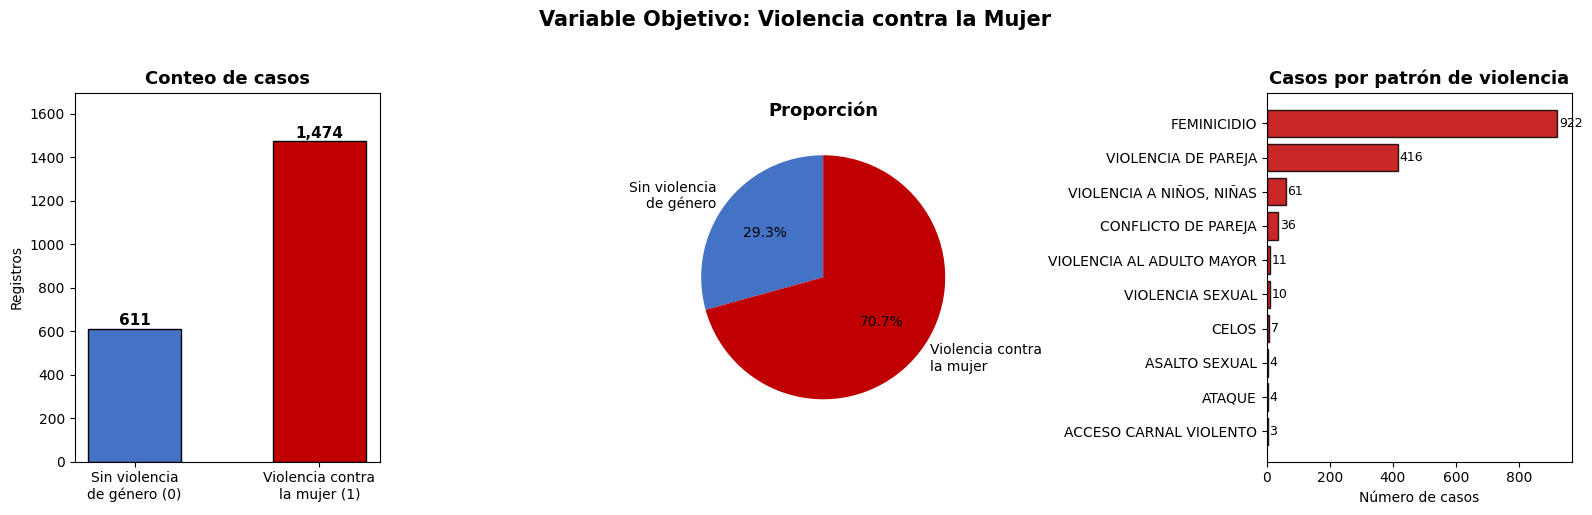

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.2 Variable objetivo: Violencia contra la Mujer (VCM)
#
# Clase 1 = VCM si cumple DOS condiciones:
#   1. SEXO_DE_LA_VICTIMA == 'MUJER'
#   2. CIRCUNSTANCIA contiene algún patrón de violencia de género
#
# Patrones confirmados en el dataset:
#   FEMINICIDIO             → 922 casos
#   VIOLENCIA DE PAREJA     → 416 casos
#   CONFLICTO DE PAREJA     →  36 casos
#   CELOS                   →   7 casos
#   ATAQUE                  →   4 casos
#   ACCESO CARNAL VIOLENTO  →   3 casos
#   ASALTO SEXUAL           → por confirmar
#   VIOLENCIA A NIÑOS/AS    → por confirmar
#   VIOLENCIA ADULTO MAYOR  → por confirmar
#   Total clase 1 (VCM)     → actualizado al correr
#
# Desbalance 66/34 → NO se necesita SMOTE.
# Se usa class_weight='balanced' como precaución.
# ─────────────────────────────────────────────────────────────

COL_SEXO          = 'SEXO_DE_LA_VICTIMA'
COL_CIRCUNSTANCIA = 'CIRCUNSTANCIA_DEL_HECHO_DETALLADA'
VALORES_MUJER     = ['MUJER']

PATRONES = [
    'FEMINICIDIO',
    'ACCESO CARNAL VIOLENTO',
    'AGRESION SEXUAL',
    'ABUSO SEXUAL',
    'LESIONES SEXUALES',
    'ATAQUE',
    'CONFLICTO DE PAREJA',
    'VIOLENCIA DE PAREJA',
    'VIOLENCIA INTRAFAMILIAR',
    'VIOLENCIA BASADA EN GEN',
    'CELOS',
    'CONTROL',
    'MALTRATO',
    'VIOLENCIA SEXUAL',
    'AMENAZA E INTIMIDACION',
    'ASALTO SEXUAL',
    'VIOLENCIA A NIÑOS, NIÑAS',
    'VIOLENCIA AL ADULTO MAYOR',
]

patron_regex = '|'.join(PATRONES)

cond_circunstancia = (
    df[COL_CIRCUNSTANCIA]
    .str.upper()
    .str.contains(patron_regex, na=False)
)
cond_sexo = df[COL_SEXO].str.upper().isin([v.upper() for v in VALORES_MUJER])

df['feminicidio'] = (cond_circunstancia & cond_sexo).astype(int)

# ── Distribución ──────────────────────────────────────────────
conteo = df['feminicidio'].value_counts().sort_index()
pct    = df['feminicidio'].value_counts(normalize=True).sort_index() * 100

print('=== DISTRIBUCIÓN VARIABLE OBJETIVO ===')
print(pd.DataFrame({'conteo': conteo, 'porcentaje_%': pct.round(2)}))

print('\n=== CASOS CAPTURADOS POR PATRÓN ===')
for patron in PATRONES:
    n = df[df[COL_CIRCUNSTANCIA].str.upper().str.contains(patron, na=False)].shape[0]
    if n > 0:
        print(f'  {patron:35} → {n:,} casos')

print('\n=== CLASE 0 — Casos sin violencia de género (top 10) ===')
print(
    df[df['feminicidio'] == 0][COL_CIRCUNSTANCIA]
    .value_counts().head(10)
)

ratio = conteo[0] / conteo[1]
print(f'\nRatio de desbalance: {ratio:.2f}:1')
print('→ Desbalance leve (66/34) — NO se necesita SMOTE')

# ── Gráficas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Barras
etiquetas  = ['Sin violencia\nde género (0)', 'Violencia contra\nla mujer (1)']
colores    = ['#4472C4', '#C00000']
bars = axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='black', width=0.5)
axes[0].set_title('Conteo de casos', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Registros')
axes[0].set_ylim(0, max(conteo.values) * 1.15)
for bar, v in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 15,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie(
    conteo.values,
    labels=['Sin violencia\nde género', 'Violencia contra\nla mujer'],
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Proporción', fontsize=13, fontweight='bold')

# Barras por patrón (solo los que tienen casos)
patrones_conteo = {
    p: df[df[COL_CIRCUNSTANCIA].str.upper().str.contains(p, na=False)].shape[0]
    for p in PATRONES
}
patrones_conteo = {k: v for k, v in patrones_conteo.items() if v > 0}
patrones_ord    = dict(sorted(patrones_conteo.items(), key=lambda x: x[1]))

axes[2].barh(list(patrones_ord.keys()), list(patrones_ord.values()),
             color='#C00000', edgecolor='black', alpha=0.85)
axes[2].set_title('Casos por patrón de violencia', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Número de casos')
for i, v in enumerate(patrones_ord.values()):
    axes[2].text(v + 5, i, str(v), va='center', fontsize=9)

plt.suptitle('Variable Objetivo: Violencia contra la Mujer',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


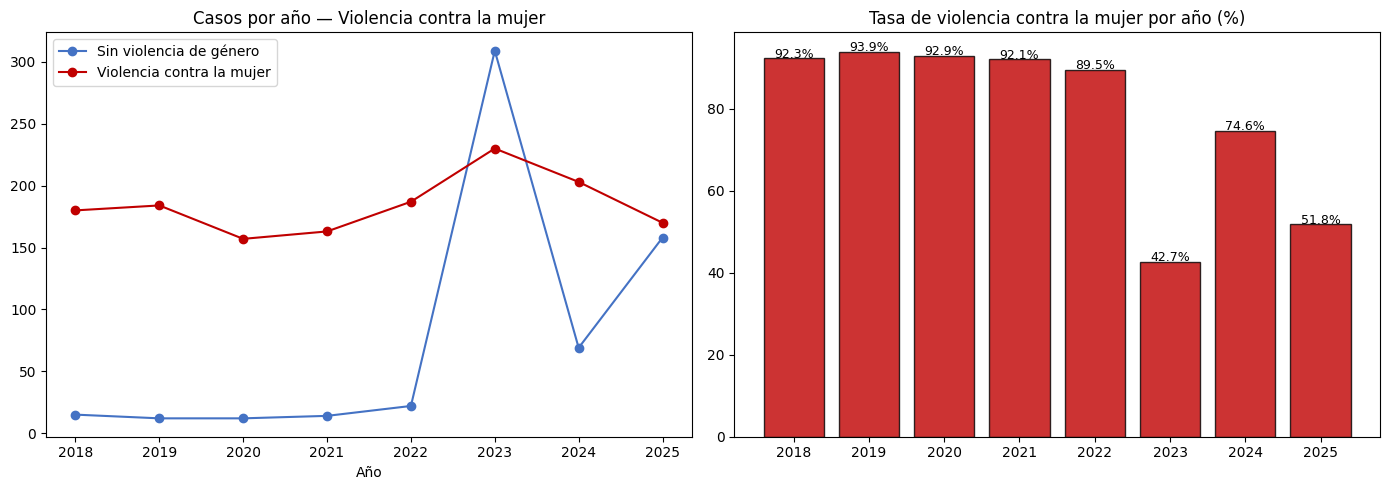

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.3 Evolución temporal
# Muestra si la tasa de feminicidio ha cambiado por año.
# Útil para detectar el efecto de la Ley 1761/2015.
# ─────────────────────────────────────────────────────────────
if 'ANO_DEL_HECHO' in df.columns:
    temporal = df.groupby(['ANO_DEL_HECHO','feminicidio']).size().unstack(fill_value=0)
    tasa     = temporal[1] / (temporal[0] + temporal[1]) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    temporal.plot(ax=axes[0], marker='o', color=['#4472C4','#C00000'])
    axes[0].set_title('Casos por año — Violencia contra la mujer', fontsize=12)
    axes[0].legend(['Sin violencia de género', 'Violencia contra la mujer'])
    axes[0].set_xlabel('Año')

    axes[1].bar(tasa.index, tasa.values, color='#C00000', edgecolor='black', alpha=0.8)
    axes[1].set_title('Tasa de violencia contra la mujer por año (%)', fontsize=12)
    for x, v in zip(tasa.index, tasa.values):
        axes[1].text(x, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

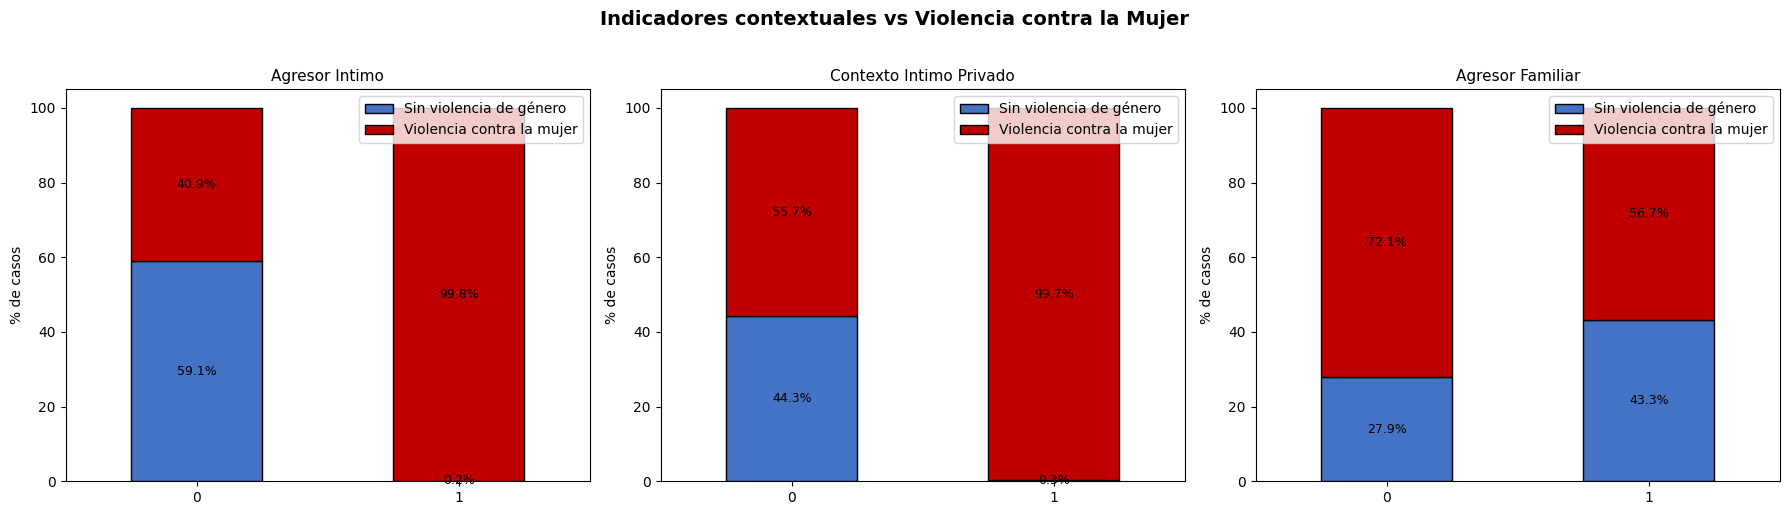

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.4 Indicadores contextuales (agresor íntimo, familiar, privado)
#
# Estas tres variables son clave teóricamente:
# el feminicidio íntimo (por pareja o ex) es el más frecuente
# en Colombia. Queremos ver si estas variables tienen poder
# discriminativo antes de entrenar el modelo.
# ─────────────────────────────────────────────────────────────
indicadores = [
    'INDICADOR_AGRESOR_INTIMO',
    'INDICADOR_CONTEXTO_INTIMO_PRIVADO',
    'INDICADOR_AGRESOR_FAMILIAR'
]
indicadores = [c for c in indicadores if c in df.columns]

if indicadores:
    fig, axes = plt.subplots(1, len(indicadores),
                             figsize=(6 * len(indicadores), 5))
    if len(indicadores) == 1:
        axes = [axes]

    for ax, col in zip(axes, indicadores):
        tabla = pd.crosstab(df[col], df['feminicidio'], normalize='index') * 100
        tabla.columns = ['Sin violencia de género', 'Violencia contra la mujer']
        tabla.plot(kind='bar', stacked=True, ax=ax,
                   color=['#4472C4','#C00000'], edgecolor='black')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)
        ax.set_title(col.replace('INDICADOR_','').replace('_',' ').title(), fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel('% de casos')
        ax.tick_params(axis='x', rotation=0)

    plt.suptitle('Indicadores contextuales vs Violencia contra la Mujer',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.5 Distribución de edad por clase
# ─────────────────────────────────────────────────────────────
col_edad = next((c for c in ['Edad','EDAD'] if c in df.columns), None)

if col_edad:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for clase, color, label in [(0,'#4472C4','Sin violencia de género'),
                                 (1,'#C00000','Violencia contra la mujer')]:
        df[df['feminicidio']==clase][col_edad].dropna().plot(
            kind='kde', ax=axes[0], color=color, label=label, linewidth=2)
    axes[0].set_title('Distribución de Edad por clase', fontsize=12)
    axes[0].set_xlabel('Edad')
    axes[0].legend()

    df.boxplot(column=col_edad, by='feminicidio', ax=axes[1],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'))
    axes[1].set_title('Boxplot Edad por clase')
    axes[1].set_xlabel('Violencia contra la mujer (0=No, 1=Sí)')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    print(df.groupby('feminicidio')[col_edad].describe().round(2))

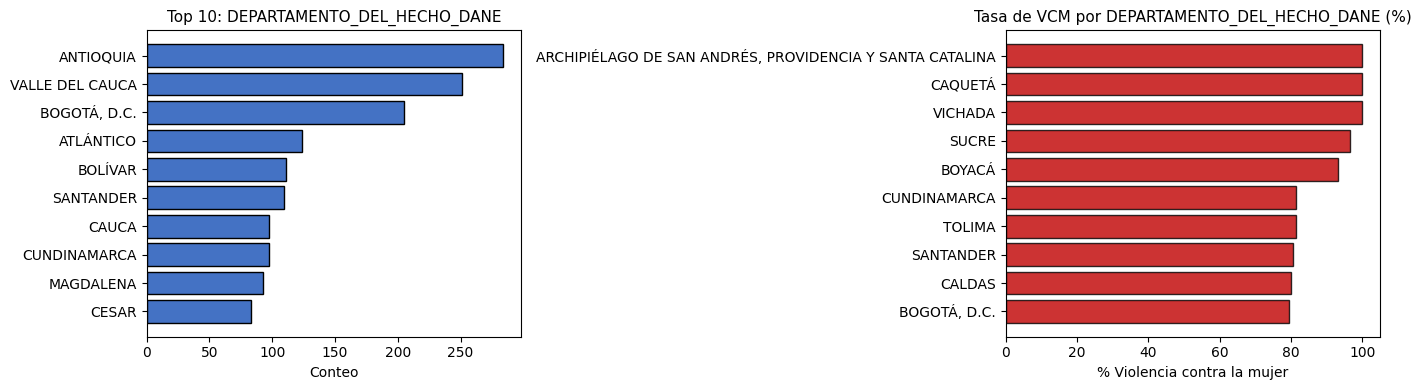

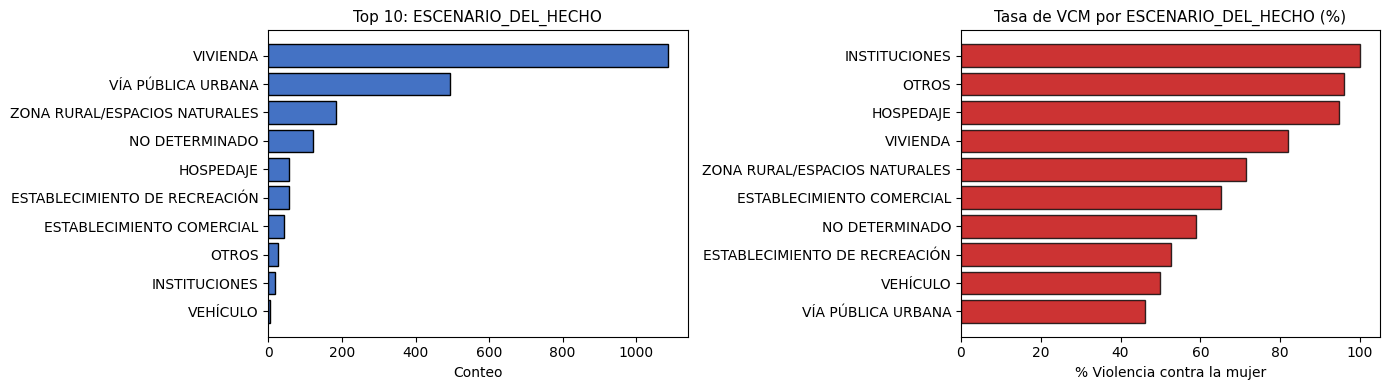

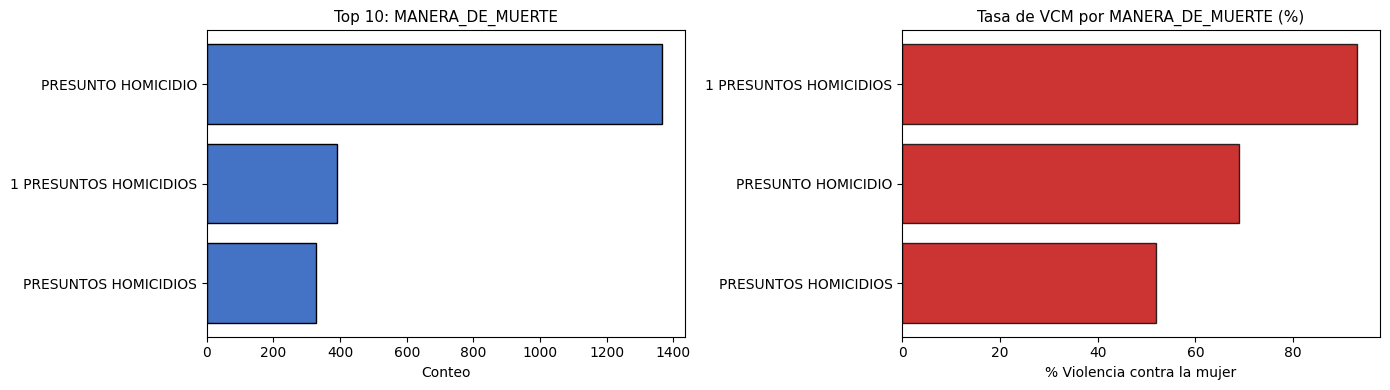

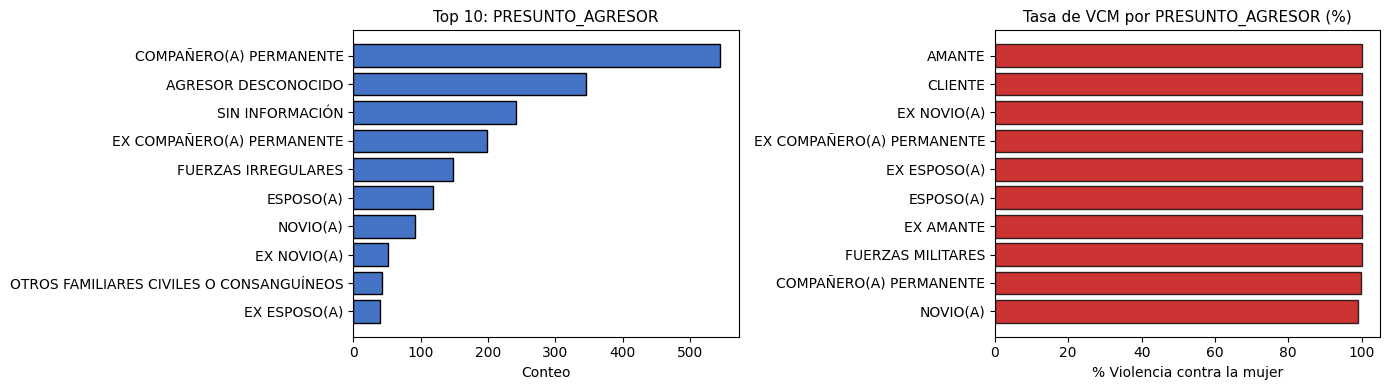

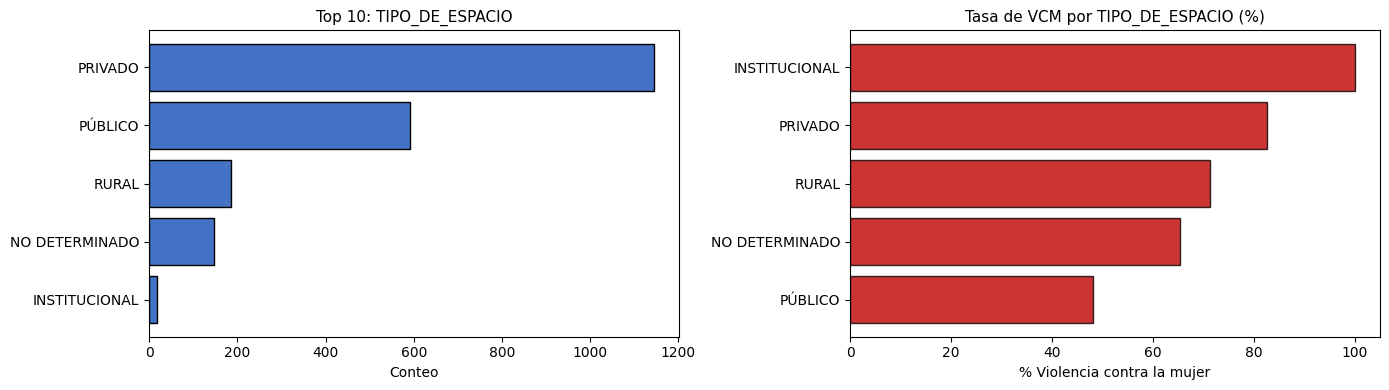

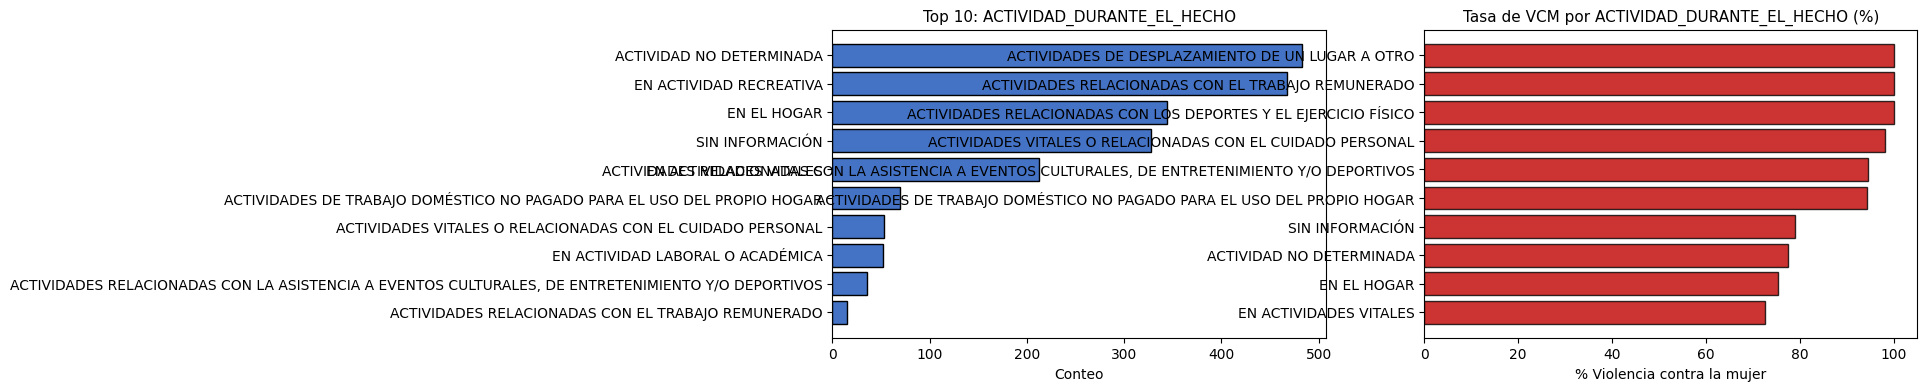

In [ ]:
# ─────────────────────────────────────────────────────────────
# 2.6 Variables categóricas clave
# Para cada variable: frecuencia absoluta + tasa de VCM
# ─────────────────────────────────────────────────────────────
# Columnas confirmadas del dataset de Medicina Legal
cols_cat_eda = [c for c in [
    'DEPARTAMENTO_DEL_HECHO_DANE',
    'ESCENARIO_DEL_HECHO',
    'MANERA_DE_MUERTE',
    'PRESUNTO_AGRESOR',
    'TIPO_DE_ESPACIO',
    'ACTIVIDAD_DURANTE_EL_HECHO'
] if c in df.columns]

for col in cols_cat_eda:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    top10 = df[col].value_counts().head(10)
    axes[0].barh(top10.index[::-1], top10.values[::-1],
                 color='#4472C4', edgecolor='black')
    axes[0].set_title(f'Top 10: {col}', fontsize=11)
    axes[0].set_xlabel('Conteo')

    tasa_col = df.groupby(col)['feminicidio'].mean().sort_values(ascending=False).head(10)
    axes[1].barh(tasa_col.index[::-1], tasa_col.values[::-1]*100,
                 color='#C00000', edgecolor='black', alpha=0.8)
    axes[1].set_title(f'Tasa de VCM por {col} (%)', fontsize=11)
    axes[1].set_xlabel('% Violencia contra la mujer')

    plt.tight_layout()
    plt.show()


## MÓDULO 3 — Preprocesamiento para Machine Learning

Este módulo está dividido en 7 pasos independientes (3A a 3G). Cada uno tiene una razón específica y debe ejecutarse en orden.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 3A — Eliminar columnas que NO deben entrar al modelo
#
# → ID / códigos DANE: identificadores sin valor predictivo
#
# → COL_CIRCUNSTANCIA: de aquí viene la variable objetivo.
#   Si la dejamos el modelo hace trampa (data leakage).
#
# → COL_SEXO (SEXO_DE_LA_VICTIMA): ya está representado en
#   la variable objetivo. Dejarlo crea un atajo artificial:
#   el modelo aprende 'si es mujer → feminicidio' en lugar
#   de aprender patrones contextuales más ricos.
#
# → DIAGNOSTICO_TOPOGRAFICO: información post-mortem,
#   no disponible en escenario de predicción real.
#
# → Fechas: sin transformación temporal adecuada pueden
#   introducir leakage temporal.
# ─────────────────────────────────────────────────────────────
COLS_DROP = [
    'ID',
    'ANO_DEL_HECHO',
    'MES_DEL_HECHO',
    'DIA_DEL_HECHO',
    'MUNICIPIO_DEL_HECHO_DANE',
    'DEPARTAMENTO_DEL_HECHO_DANE',
    COL_CIRCUNSTANCIA,              # CIRCUNSTANCIA_DEL_HECHO_DETALLADA
    COL_SEXO,                       # SEXO_DE_LA_VICTIMA
    'DIAGNOSTICO_TOPOGRAFICO_DE_LA_LESION_FATAL'
]

cols_drop_ok = [c for c in COLS_DROP if c in df.columns]
df_ml = df.drop(columns=cols_drop_ok)

print(f'Columnas eliminadas ({len(cols_drop_ok)}): {cols_drop_ok}')
print(f'Shape resultante: {df_ml.shape}')


Columnas eliminadas (9): ['ID', 'ANO_DEL_HECHO', 'MES_DEL_HECHO', 'DIA_DEL_HECHO', 'MUNICIPIO_DEL_HECHO_DANE', 'DEPARTAMENTO_DEL_HECHO_DANE', 'CIRCUNSTANCIA_DEL_HECHO_DETALLADA', 'SEXO_DE_LA_VICTIMA', 'DIAGNOSTICO_TOPOGRAFICO_DE_LA_LESION_FATAL']
Shape resultante: (2085, 24)


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3B — Separar X (variables predictoras) e y (variable objetivo)
#
# X = todo lo que el modelo puede ver para hacer la predicción
# y = lo que el modelo tiene que predecir (0 o 1)
#
# Este paso debe hacerse ANTES de cualquier transformación
# sobre X, para evitar que la variable objetivo contamine
# las variables de entrada.
# ─────────────────────────────────────────────────────────────
y = df_ml['feminicidio']                    # vector objetivo
X = df_ml.drop(columns=['feminicidio'])     # matriz de features

print(f'X shape: {X.shape}  →  {X.shape[0]:,} registros, {X.shape[1]} variables')
print(f'y distribución:\n{y.value_counts()}')

X shape: (2085, 23)  →  2,085 registros, 23 variables
y distribución:
feminicidio
1    1474
0     611
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3C — Imputación de valores nulos
#
# Los modelos de sklearn no aceptan NaN. Hay que decidir
# qué valor poner donde falta información.
#
# Para numéricas usamos la MEDIANA (no el promedio).
# ¿Por qué mediana?  Porque es robusta a valores extremos.
# Ejemplo: si la edad tiene un outlier de 99, el promedio
# se desplaza hacia arriba pero la mediana no se mueve.
#
# Para categóricas usamos la MODA (valor más frecuente).
# Mantiene la distribución original de la variable sin
# inventar categorías nuevas.
#
# IMPORTANTE: los imputadores se guardan para aplicarlos
# igual sobre datos nuevos en producción.
# ─────────────────────────────────────────────────────────────
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

print(f'Variables numéricas  ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

if num_cols:
    imp_num = SimpleImputer(strategy='median')
    X[num_cols] = imp_num.fit_transform(X[num_cols])

if cat_cols:
    imp_cat = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = imp_cat.fit_transform(X[cat_cols])

print(f'\nNulos restantes: {X.isnull().sum().sum()} ')

Variables numéricas  (6): ['INDICADOR_ALTA_SEVERIDAD_O_VIOLENCIA', 'INDICADOR_ZONA_VITAL', 'INDICADOR_AGRESOR_INTIMO', 'INDICADOR_AGRESOR_FAMILIAR', 'INDICADOR_AGRESOR_CONOCIDO', 'INDICADOR_CONTEXTO_INTIMO_PRIVADO']
Variables categóricas (17): ['GRUPO_DE_EDAD_QUINQUENAL', 'GRUPO_MAYOR_MENOR_DE_EDAD', 'EDAD_DEL_CICLO_VITAL', 'CICLO_VITAL', 'ESTADO_CIVIL', 'PAIS_DE_NACIMIENTO', 'ESCOLARIDAD', 'TIPO_DE_ESPACIO', 'ESCENARIO_DEL_HECHO', 'ACTIVIDAD_DURANTE_EL_HECHO', 'MANERA_DE_MUERTE', 'PRESUNTO_AGRESOR', 'PRESUNTO_AGRESOR_RECATEGORIZADO', 'ANCESTRO_RACIAL', 'ORIENTACION_SEXUAL', 'IDENTIDAD_DE_GENERO', 'TRANSGENERO']

Nulos restantes: 0 


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3D — Encoding de variables categóricas
#
# Los modelos de ML solo entienden números. Hay que convertir
# texto a números. Usamos dos estrategias según la cantidad
# de categorías únicas de cada variable:
#
# ONE-HOT ENCODING (≤ 10 categorías):
# Crea una columna binaria por cada categoría.
# Ejemplo: SEXO [M, F] → SEXO_M [0,1], SEXO_F [0,1]
# Ventaja: no asume orden entre categorías.
# Desventaja: aumenta dimensiones si hay muchas categorías.
#
# LABEL ENCODING (> 10 categorías):
# Asigna un número entero a cada categoría.
# Ejemplo: DEPARTAMENTO [Antioquia, Bogotá, ...] → [0, 1, ...]
# Ventaja: no explota las dimensiones.
# Desventaja: implica un orden artificial (Antioquia < Bogotá)
# que los modelos basados en árboles manejan bien pero
# Logistic Regression puede malinterpretar.
# ─────────────────────────────────────────────────────────────
le = LabelEncoder()

cols_ohe = [c for c in cat_cols if X[c].nunique() <= 10]
cols_le  = [c for c in cat_cols if X[c].nunique() >  10]

print(f'OHE   ({len(cols_ohe)}): {cols_ohe}')
print(f'Label ({len(cols_le)}):  {cols_le}')

for col in cols_le:
    X[col] = le.fit_transform(X[col].astype(str))

if cols_ohe:
    X = pd.get_dummies(X, columns=cols_ohe, drop_first=True)

print(f'\nShape final de X: {X.shape}')

OHE   (14): ['GRUPO_MAYOR_MENOR_DE_EDAD', 'EDAD_DEL_CICLO_VITAL', 'CICLO_VITAL', 'ESTADO_CIVIL', 'PAIS_DE_NACIMIENTO', 'ESCOLARIDAD', 'TIPO_DE_ESPACIO', 'ESCENARIO_DEL_HECHO', 'MANERA_DE_MUERTE', 'PRESUNTO_AGRESOR_RECATEGORIZADO', 'ANCESTRO_RACIAL', 'ORIENTACION_SEXUAL', 'IDENTIDAD_DE_GENERO', 'TRANSGENERO']
Label (3):  ['GRUPO_DE_EDAD_QUINQUENAL', 'ACTIVIDAD_DURANTE_EL_HECHO', 'PRESUNTO_AGRESOR']

Shape final de X: (2085, 72)


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3E — Tratamiento de outliers (Winsorización)
#
# En lugar de eliminar filas con valores extremos (perdemos
# datos), aplicamos winsorización: recortamos los valores
# fuera del rango [percentil 1%, percentil 99%].
#
# Ejemplo: si la edad tiene un registro de 150 años (error),
# lo reemplazamos por el valor del percentil 99 de la edad.
#
# Random Forest y XGBoost son robustos a outliers por diseño.
# Pero Logistic Regression sí los necesita controlados
# para converger correctamente.
# ─────────────────────────────────────────────────────────────
for col in num_cols:
    if col in X.columns:
        p01 = X[col].quantile(0.01)
        p99 = X[col].quantile(0.99)
        antes = X[col].copy()
        X[col] = X[col].clip(p01, p99)
        n_clip = (antes != X[col]).sum()
        if n_clip > 0:
            print(f'{col}: {n_clip} valores recortados')

print('\n Winsorización aplicada (1%–99%)')


 Winsorización aplicada (1%–99%)


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3F — División Train / Test estratificada
#
# Dividimos en 80% entrenamiento y 20% prueba.
#
# El parámetro stratify=y es CRÍTICO con datos desbalanceados:
# garantiza que la proporción de feminicidios sea la misma
# en train y en test. Sin esto, podría pasar que el test
# tenga muy pocos feminicidios y las métricas sean engañosas.
#
# random_state=42 hace el split reproducible. Cualquier
# persona que corra este código obtiene exactamente el
# mismo split.
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # ← mantiene proporción de clases
)

print(f'Train: {X_train.shape[0]:,} registros  |  Test: {X_test.shape[0]:,} registros')
print(f'Violencia VCM en train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Violencia VCM en test:  {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')

Train: 1,668 registros  |  Test: 417 registros
Violencia VCM en train: 1,179 (70.68%)
Violencia VCM en test:  295  (70.74%)


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3G — Escalado con StandardScaler
#
# Estandariza las variables numéricas para que tengan
# media=0 y desviación estándar=1.
#
# ¿Para qué sirve?
# Sin escalado, una variable como 'Edad' (rango 0–90) domina
# sobre una variable como 'Indicador' (rango 0–1) en modelos
# como Logistic Regression, que son sensibles a la escala.
#
# Random Forest y XGBoost NO necesitan escalado porque
# trabajan con umbrales en cada variable de forma independiente.
#
# REGLA DE ORO: el scaler se AJUSTA solo en train.
# Sobre test solo se APLICA (transform). Si lo ajustaras
# en test, estarías filtrando información del futuro
# al modelo (data leakage).
# ─────────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # aprende media y std de train
X_test_scaled  = scaler.transform(X_test)        # aplica la misma escala de train

print(' Escalado listo (StandardScaler)')
print('   X_train_scaled se usará solo en Logistic Regression')

 Escalado listo (StandardScaler)
   X_train_scaled se usará solo en Logistic Regression


In [ ]:
# ─────────────────────────────────────────────────────────────
# 3H — SMOTE: NO se aplica en este proyecto
#
# SMOTE genera casos sintéticos de la clase minoritaria para
# equilibrar datasets muy desbalanceados (ej: 95% vs 5%).
#
# En este dataset el desbalance es 66% vs 34% — leve.
# Con ese ratio los modelos aprenden bien ambas clases
# usando class_weight='balanced', que ajusta internamente
# los pesos sin necesidad de crear datos artificiales.
#
# Aplicar SMOTE aquí sería innecesario e incluso contraproducente:
# generaría ruido sintético donde los datos reales son suficientes.
# ─────────────────────────────────────────────────────────────

# Se usan directamente X_train y y_train sin sobremuestreo
X_train_sm = X_train
y_train_sm = y_train

print('Sin SMOTE — desbalance 66/34 no lo requiere')
print(f'Train: {y_train.value_counts().rename({0: "Sin VG", 1: "VCM"}).to_dict()}')


Sin SMOTE — desbalance 66/34 no lo requiere
Train: {'VCM': 1179, 'Sin VG': 489}


## MÓDULO 4 — Modelado

### ¿Qué es un modelo de clasificación binaria?

Es un algoritmo que aprende a separar dos grupos. En este caso:
- **Clase 0:** Sin violencia de género
- **Clase 1:** Violencia contra la mujer

El modelo recibe las características de un caso (las columnas de X) y devuelve una **probabilidad entre 0 y 1**. Si esa probabilidad supera un umbral (por defecto 0.5), predice violencia contra la mujer.

### ¿Por qué tres modelos?

Cada algoritmo tiene fortalezas distintas. Entrenar los tres y comparar permite elegir el más adecuado para estos datos específicos.

| Modelo | Tipo | Fortaleza principal |
|---|---|---|
| Random Forest | Árboles en paralelo | Robusto, estable, importancia de variables |
| XGBoost | Árboles en serie (boosting) | Alta precisión en datos tabulares |
| Logistic Regression | Ecuación lineal | Interpretable, baseline de referencia |

In [ ]:
# ─────────────────────────────────────────────────────────────
# Función auxiliar de evaluación
# Se llama igual para los 3 modelos, asegurando comparación
# consistente. Genera classification_report + ROC-AUC +
# Average Precision + matriz de confusión visual.
# ─────────────────────────────────────────────────────────────
def evaluar_modelo(nombre, y_real, y_pred, y_prob=None):
    print(f'\n{"="*55}')
    print(f'  MODELO: {nombre}')
    print(f'{"="*55}')
    print(classification_report(
        y_real, y_pred,
        target_names=['Sin violencia de género','Violencia contra la mujer']
    ))

    resultados = {
        'modelo':         nombre,
        'accuracy':       accuracy_score(y_real, y_pred),
        'f1_vcm': f1_score(y_real, y_pred),
        'roc_auc':        None
    }

    if y_prob is not None:
        auc = roc_auc_score(y_real, y_prob)
        ap  = average_precision_score(y_real, y_prob)
        print(f'ROC-AUC:           {auc:.4f}')
        print(f'Average Precision: {ap:.4f}')
        resultados['roc_auc'] = auc

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred,
        display_labels=['Sin VG','Violencia contra la mujer'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Matriz de Confusión — {nombre}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return resultados

print('Función evaluar_modelo() lista')

Función evaluar_modelo() lista



  MODELO: Random Forest
                           precision    recall  f1-score   support

  Sin violencia de género       0.76      0.95      0.84       122
Violencia contra la mujer       0.98      0.87      0.92       295

                 accuracy                           0.90       417
                macro avg       0.87      0.91      0.88       417
             weighted avg       0.91      0.90      0.90       417

ROC-AUC:           0.9705
Average Precision: 0.9889


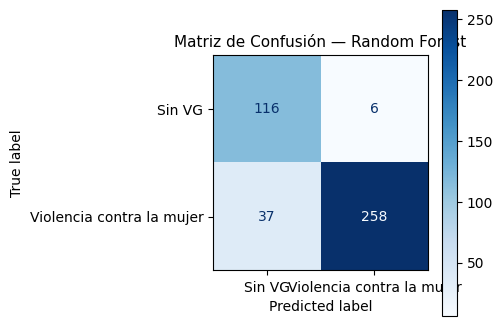

In [ ]:
# ─────────────────────────────────────────────────────────────
# 4A — Random Forest
#
# ¿Cómo funciona?
# Entrena N árboles de decisión (n_estimators=300), cada uno
# con una muestra aleatoria de los datos y de las variables.
# La predicción final es el voto mayoritario de todos los árboles.
# Al promediar muchos árboles, se reduce la varianza y el
# sobreajuste que tendría un solo árbol profundo.
#
# Parámetros clave explicados:
# n_estimators=300    → 300 árboles. Más árboles = menos varianza,
#                       pero más tiempo de entrenamiento.
# max_depth=12        → cada árbol puede tener máximo 12 niveles.
#                       Limita sobreajuste (un árbol sin límite
#                       memoriza cada registro de entrenamiento).
# min_samples_leaf=5  → cada hoja (nodo final) debe tener al menos
#                       5 registros. Evita ramas con un solo caso.
# class_weight='balanced' → asigna más peso a la clase minoritaria
#                           (sin violencia de género) en la función de pérdida.
#                           Penaliza más los errores sobre esa clase.
# ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            # usa todos los núcleos disponibles
)
rf.fit(X_train_sm, y_train_sm)   # X_train_sm = X_train (sin SMOTE, 66/34 no lo requiere)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]   # probabilidad de ser VCM

res_rf = evaluar_modelo('Random Forest', y_test, y_pred_rf, y_prob_rf)

Ratio de clases (negativo/positivo): 0.41

  MODELO: XGBoost
                           precision    recall  f1-score   support

  Sin violencia de género       0.80      0.95      0.87       122
Violencia contra la mujer       0.98      0.90      0.94       295

                 accuracy                           0.92       417
                macro avg       0.89      0.93      0.90       417
             weighted avg       0.93      0.92      0.92       417

ROC-AUC:           0.9727
Average Precision: 0.9898


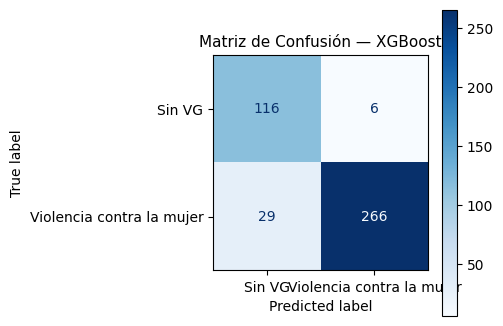

In [ ]:
# ─────────────────────────────────────────────────────────────
# 4B — XGBoost
#
# ¿Cómo funciona?
# A diferencia de Random Forest (árboles en paralelo),
# XGBoost entrena árboles EN SERIE: cada árbol nuevo corrige
# los errores del anterior. Es como un equipo donde el
# segundo jugador compensa las fallas del primero, el
# tercero las del segundo, y así sucesivamente.
# Esto se llama GRADIENT BOOSTING.
#
# scale_pos_weight: ajusta el peso de cada clase.
# Se calcula como: casos negativos / casos positivos.
# Con 66/34 el ratio es ~0.5 — la clase negativa es la minoritaria.
#
# learning_rate=0.05: qué tanto aprende cada árbol nuevo.
# Valores pequeños + muchos árboles = aprendizaje más suave
# y menos sobreajuste.
# ─────────────────────────────────────────────────────────────
ratio_clases = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio de clases (negativo/positivo): {ratio_clases:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio_clases,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)   # XGBoost con scale_pos_weight, sin SMOTE

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

res_xgb = evaluar_modelo('XGBoost', y_test, y_pred_xgb, y_prob_xgb)


  MODELO: Logistic Regression
                           precision    recall  f1-score   support

  Sin violencia de género       0.74      0.93      0.83       122
Violencia contra la mujer       0.97      0.86      0.91       295

                 accuracy                           0.88       417
                macro avg       0.85      0.90      0.87       417
             weighted avg       0.90      0.88      0.89       417

ROC-AUC:           0.9649
Average Precision: 0.9868


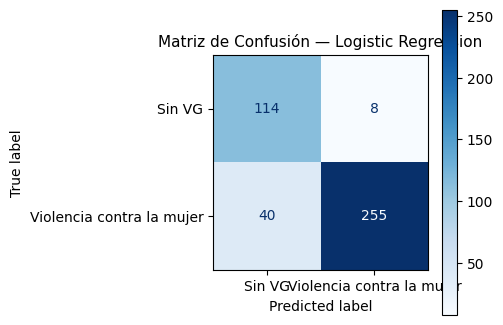

In [ ]:
# ─────────────────────────────────────────────────────────────
# 4C — Logistic Regression (baseline)
#
# ¿Cómo funciona?
# Aprende una ecuación lineal que combina las variables
# predictoras y la transforma a una probabilidad usando
# la función sigmoide (curva en S entre 0 y 1).
# Es el modelo más simple e interpretable.
#
# Se usa como BASELINE: si los modelos complejos (RF, XGBoost)
# no superan a la regresión logística, hay un problema
# en los datos o en el preprocesamiento.
#
# C=1.0: controla la regularización (penalización de
# coeficientes grandes). C pequeño = más regularización.
#
# Usa X_train_scaled porque LR es sensible a la escala.
# ─────────────────────────────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42
)
lr.fit(X_train_scaled, y_train)   # ← datos escalados

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

res_lr = evaluar_modelo('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

=== COMPARACIÓN FINAL ===
                     accuracy  f1_vcm  roc_auc
modelo                                        
Random Forest          0.8969  0.9231   0.9705
XGBoost                0.9161  0.9383   0.9727
Logistic Regression    0.8849  0.9140   0.9649


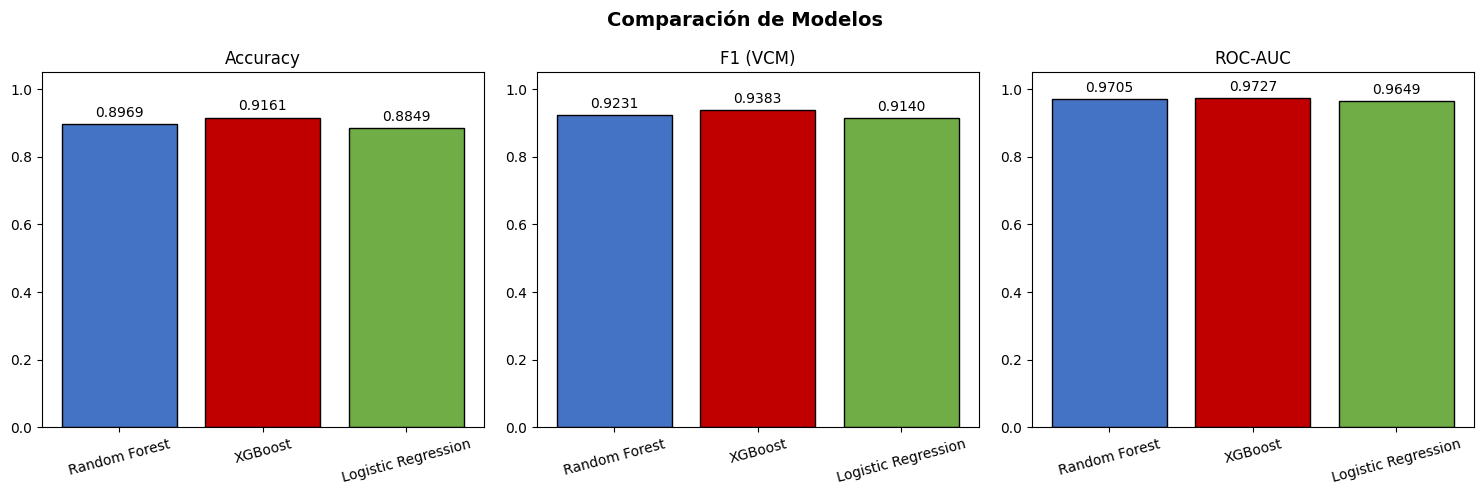

In [ ]:
# ─────────────────────────────────────────────────────────────
# 4D — Comparación de los 3 modelos
#
# ¿Qué métrica priorizar?
#
# ACCURACY: % de predicciones correctas.
# → Con desbalance puede ser engañosa.
#
# F1 (clase VCM): media armónica entre precisión y recall
# para la clase positiva (violencia contra la mujer).
# → Métrica principal: penaliza falsos negativos y positivos.
#
# ROC-AUC: probabilidad de que el modelo asigne mayor
# probabilidad a un caso de VCM real vs uno que no lo es.
# → 0.5 = modelo aleatorio, 1.0 = modelo perfecto.
# ─────────────────────────────────────────────────────────────
comparacion = pd.DataFrame([res_rf, res_xgb, res_lr]).set_index('modelo').round(4)
print('=== COMPARACIÓN FINAL ===')
print(comparacion)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = ['#4472C4','#C00000','#70AD47']

for ax, col, titulo in zip(axes,
    ['accuracy','f1_vcm','roc_auc'],
    ['Accuracy','F1 (VCM)','ROC-AUC']):
    bars = ax.bar(comparacion.index, comparacion[col],
                  color=colores, edgecolor='black')
    ax.set_title(titulo, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## MÓDULO 5 — Evaluación profunda

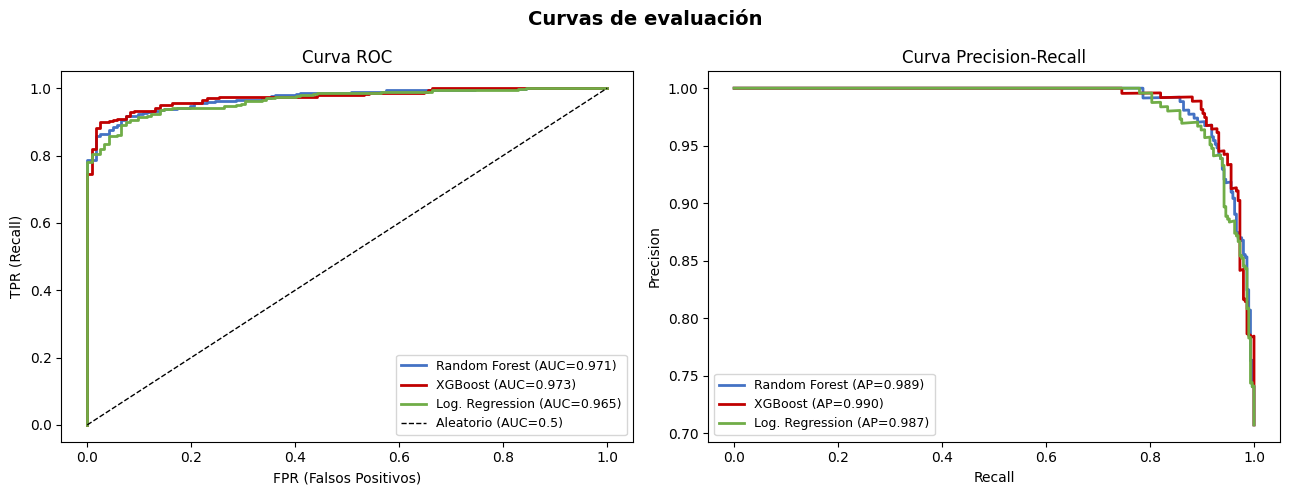

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5A — Curvas ROC y Precision-Recall
#
# CURVA ROC:
# Muestra el tradeoff entre detectar casos reales de VCM
# (TPR = True Positive Rate = Recall) vs clasificar mal
# los negativos (FPR = False Positive Rate).
# El área bajo la curva (AUC) resume el rendimiento en todos
# los umbrales posibles.
#
# CURVA PRECISION-RECALL:
# Más informativa con desbalance porque ignora los verdaderos
# negativos (que son muchos y fáciles de predecir).
# Muestra el tradeoff entre:
# - PRECISIÓN: de los que predigo como VCM, ¿cuántos realmente lo son?
# - RECALL: de todos los casos reales de VCM, ¿cuántos detecta el modelo?
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos_eval = [
    ('Random Forest',     y_prob_rf,  '#4472C4'),
    ('XGBoost',           y_prob_xgb, '#C00000'),
    ('Log. Regression',   y_prob_lr,  '#70AD47')
]

for nombre, y_prob, color in modelos_eval:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.5)')
axes[0].set_title('Curva ROC', fontsize=12)
axes[0].set_xlabel('FPR (Falsos Positivos)')
axes[0].set_ylabel('TPR (Recall)')
axes[0].legend(fontsize=9)

for nombre, y_prob, color in modelos_eval:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{nombre} (AP={ap:.3f})')

axes[1].set_title('Curva Precision-Recall', fontsize=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.suptitle('Curvas de evaluación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

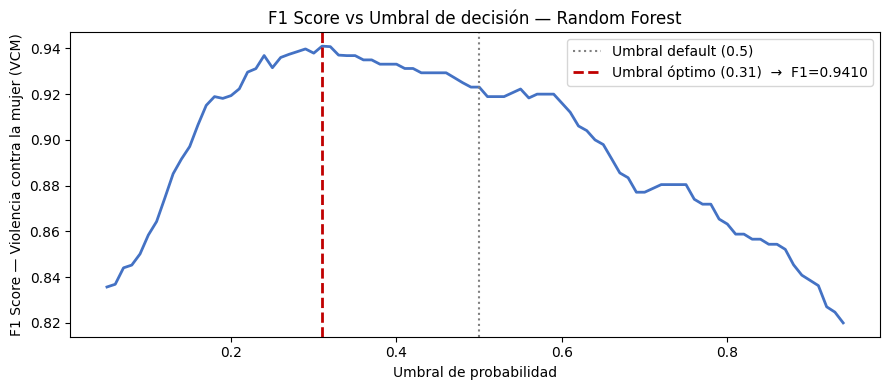


=== EVALUACIÓN CON UMBRAL ÓPTIMO (0.31) ===
                           precision    recall  f1-score   support

  Sin violencia de género       0.82      0.92      0.87       122
Violencia contra la mujer       0.96      0.92      0.94       295

                 accuracy                           0.92       417
                macro avg       0.89      0.92      0.90       417
             weighted avg       0.92      0.92      0.92       417



In [ ]:
# ─────────────────────────────────────────────────────────────
# 5B — Optimización del umbral de decisión
#
# Por defecto el modelo dice 'VCM' si prob >= 0.5.
# Pero ese 0.5 puede no ser óptimo.
#
# Si bajamos el umbral a 0.3:
# → más casos clasificados como VCM
# → RECALL sube (detectamos más reales)
# → PRECISIÓN baja (más falsos positivos)
#
# Si subimos el umbral a 0.7:
# → menos casos clasificados como VCM
# → PRECISIÓN sube (predicciones más seguras)
# → RECALL baja (perdemos casos reales)
#
# Buscamos el umbral que maximiza el F1, que balancea
# precisión y recall.
# ─────────────────────────────────────────────────────────────
umbrales  = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_test, (y_prob_rf >= u).astype(int), zero_division=0)
             for u in umbrales]

umbral_optimo = umbrales[np.argmax(f1_scores)]
f1_optimo     = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(umbrales, f1_scores, color='#4472C4', lw=2)
plt.axvline(0.5,           color='gray',   linestyle=':', lw=1.5, label='Umbral default (0.5)')
plt.axvline(umbral_optimo, color='#C00000', linestyle='--', lw=2,
            label=f'Umbral óptimo ({umbral_optimo:.2f})  →  F1={f1_optimo:.4f}')
plt.title('F1 Score vs Umbral de decisión — Random Forest', fontsize=12)
plt.xlabel('Umbral de probabilidad')
plt.ylabel('F1 Score — Violencia contra la mujer (VCM)')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluación final con umbral óptimo
y_pred_optimo = (y_prob_rf >= umbral_optimo).astype(int)
print(f'\n=== EVALUACIÓN CON UMBRAL ÓPTIMO ({umbral_optimo:.2f}) ===')
print(classification_report(y_test, y_pred_optimo,
                             target_names=['Sin violencia de género','Violencia contra la mujer']))

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5C — Validación cruzada estratificada (5-fold)
#
# El split 80/20 anterior es una sola evaluación.
# Puede ser 'afortunada' o 'desafortunada' según qué
# registros quedaron en test.
#
# La validación cruzada divide el dataset en 5 partes:
# ronda 1: entrena en folds 2-3-4-5, evalúa en fold 1
# ronda 2: entrena en folds 1-3-4-5, evalúa en fold 2
# ... y así sucesivamente.
#
# Al final tienes 5 métricas independientes. La media y
# la desviación estándar muestran si el modelo es estable
# o si varía mucho según qué datos ve.
# ─────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1',      n_jobs=-1)
scores_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('=== VALIDACIÓN CRUZADA 5-FOLD — Random Forest ===')
print(f'F1 por fold:      {scores_f1.round(4)}')
print(f'F1 media:         {scores_f1.mean():.4f}  ±  {scores_f1.std():.4f}')
print(f'\nROC-AUC por fold: {scores_auc.round(4)}')
print(f'ROC-AUC media:    {scores_auc.mean():.4f}  ±  {scores_auc.std():.4f}')
print('\n→ Desviación estándar alta (>0.03) indica inestabilidad del modelo.')

=== VALIDACIÓN CRUZADA 5-FOLD — Random Forest ===
F1 por fold:      [0.9186 0.9173 0.9317 0.9138 0.9071]
F1 media:         0.9177  ±  0.0080

ROC-AUC por fold: [0.9612 0.9658 0.9716 0.9722 0.9455]
ROC-AUC media:    0.9632  ±  0.0097

→ Desviación estándar alta (>0.03) indica inestabilidad del modelo.


## MÓDULO 6 — Interpretabilidad del modelo

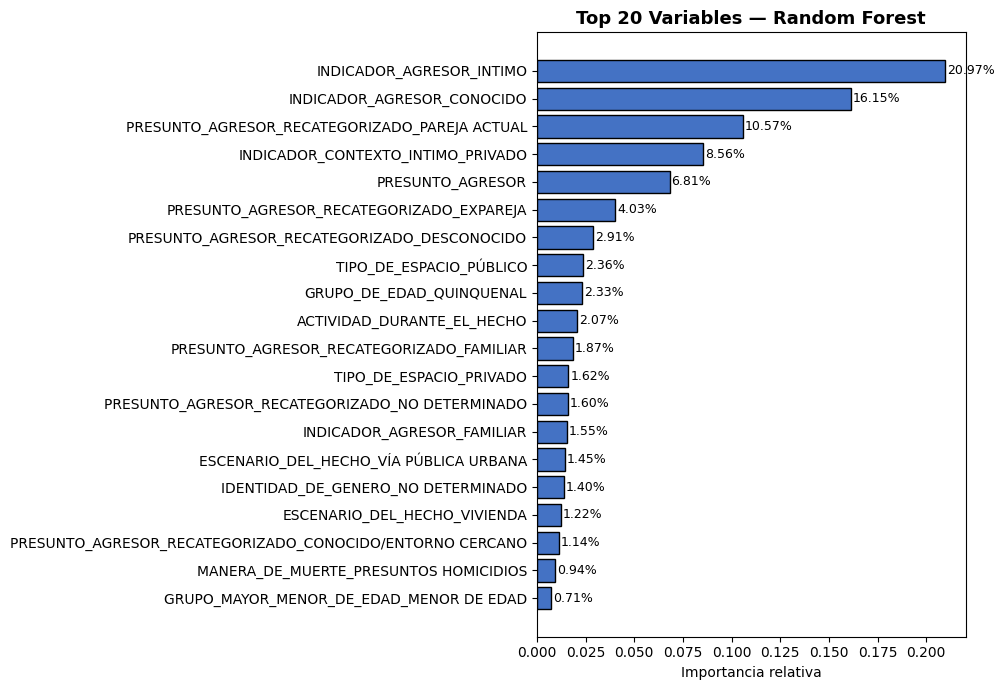

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6A — Feature Importance (Random Forest)
#
# Cada árbol de decisión divide los datos usando umbrales
# en las variables. Feature Importance mide cuánto mejora
# la pureza de los nodos al usar cada variable (Gini Importance).
#
# Limitación: indica CUÁNTO importa cada variable pero NO
# la DIRECCIÓN del efecto. Para eso usamos SHAP.
# ─────────────────────────────────────────────────────────────
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importancias.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color='#4472C4', edgecolor='black')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=9)
ax.set_title('Top 20 Variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

Tipo de shap_values: <class 'numpy.ndarray'>
Formato array 3D → shape: (417, 72, 2)

=== SHAP — Impacto global de variables ===


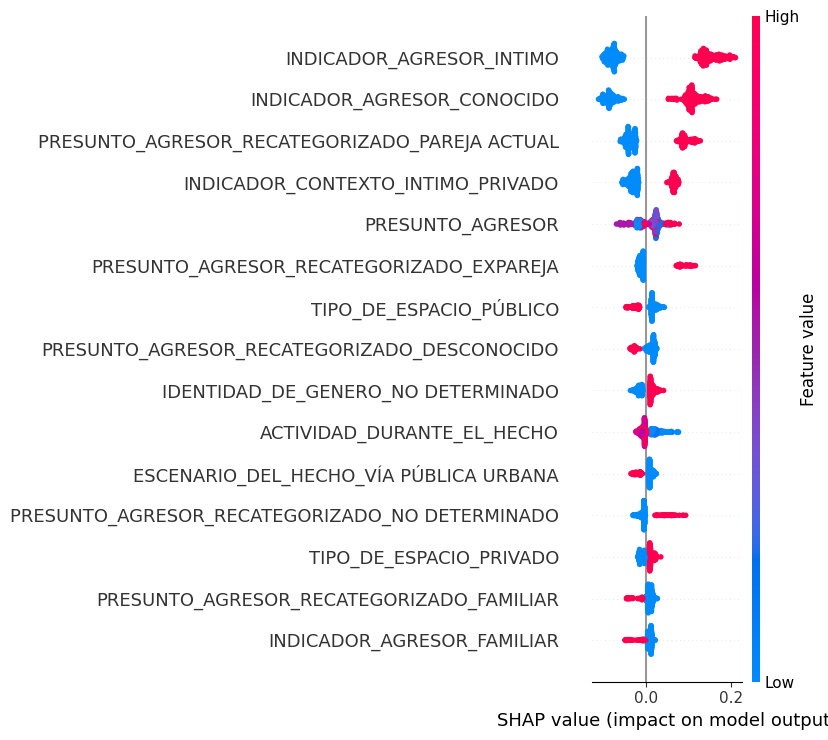

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6B — SHAP Values: interpretabilidad global
#
# ¿Qué es SHAP?
# Viene de la teoría de juegos (Shapley values). Para cada
# predicción, calcula la contribución MARGINAL de cada variable
# comparando todas las combinaciones posibles de variables.
#
# Ventaja sobre Feature Importance:
# → Muestra la DIRECCIÓN: si una variable aumenta o disminuye
#   la probabilidad de que sea violencia contra la mujer (VCM).
# → Es local: explica cada predicción individualmente.
#
# El beeswarm plot muestra:
# → Eje X: valor SHAP (positivo = empuja hacia VCM,
#           negativo = empuja hacia sin VCM)
# → Color: valor de la variable (rojo=alto, azul=bajo)
#
# ── FIX SHAP ─────────────────────────────────────────────────
# SHAP >= 0.42 devuelve array 3D: (muestras, features, clases)
# SHAP <  0.42 devuelve lista:   [array_clase0, array_clase1]
# El código detecta el formato automáticamente.
# ─────────────────────────────────────────────────────────────
N_SHAP = min(500, len(X_test))
X_shap = X_test.iloc[:N_SHAP]

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

print(f'Tipo de shap_values: {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'Formato lista → shap_values[1].shape: {shap_values[1].shape}')
    sv_vcm = shap_values[1]
else:
    print(f'Formato array 3D → shape: {shap_values.shape}')
    sv_vcm = shap_values[:, :, 1]

print('\n=== SHAP — Impacto global de variables ===')
shap.summary_plot(sv_vcm, X_shap, max_display=15, show=True)

=== Explicación caso #1 (predicción: Violencia contra la mujer) ===


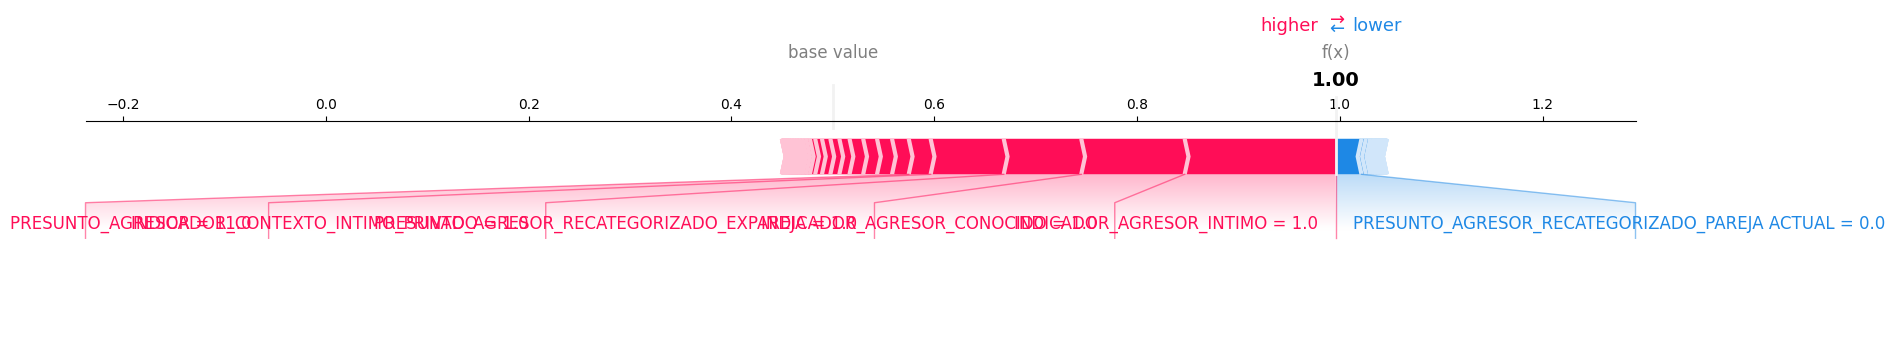

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6C — SHAP: explicación de un caso individual
#
# El force_plot muestra para UN caso específico:
# → Variables en rojo: empujaron la predicción hacia VCM
# → Variables en azul: la empujaron en contra
# → El ancho de cada barra es proporcional a la magnitud
#
# Esto responde: ¿por qué el modelo tomó ESTA decisión
# para ESTE caso específico?
#
# ── FIX: misma lógica de detección de formato ────────────────
# ─────────────────────────────────────────────────────────────
idx_vcm = np.where(y_pred_rf[:N_SHAP] == 1)[0]

if len(idx_vcm) > 0:
    caso = idx_vcm[0]
    print(f'=== Explicación caso #{caso} (predicción: Violencia contra la mujer) ===')

    if isinstance(shap_values, list):
        sv_caso    = shap_values[1][caso]
        base_value = explainer.expected_value[1]
    else:
        sv_caso    = shap_values[caso, :, 1]
        base_value = (
            explainer.expected_value[1]
            if hasattr(explainer.expected_value, '__len__')
            else explainer.expected_value
        )

    shap.force_plot(base_value, sv_caso, X_shap.iloc[caso], matplotlib=True)
else:
    print('No hay casos predichos como violencia contra la mujer en la muestra de SHAP.')

## MÓDULO 7 — Exportar el modelo

In [ ]:
# ─────────────────────────────────────────────────────────────
# 7 — Guardar todos los artefactos del pipeline
#
# Para usar el modelo en producción sobre datos nuevos,
# necesitas guardar NO solo el modelo sino también todos
# los transformadores que aplicaste en el preprocesamiento.
# De lo contrario, los datos nuevos entrarán al modelo
# con una escala diferente y las predicciones serán erróneas.
# ─────────────────────────────────────────────────────────────
import joblib

joblib.dump(rf,      'modelo_rf_vcm.pkl')
joblib.dump(xgb,     'modelo_xgb_vcm.pkl')
joblib.dump(scaler,  'scaler_vcm.pkl')
joblib.dump(imp_num, 'imputer_num_vcm.pkl')
joblib.dump(imp_cat, 'imputer_cat_vcm.pkl')

print(' Artefactos exportados:')
print('   modelo_rf_vcm.pkl   → Random Forest entrenado')
print('   modelo_xgb_vcm.pkl  → XGBoost entrenado')
print('   scaler_vcm.pkl      → StandardScaler (para Logistic Regression)')
print('   imputer_num_vcm.pkl → Imputador numérico (mediana)')
print('   imputer_cat_vcm.pkl → Imputador categórico (moda)')
print()
print('Para cargar en producción:')
print("   modelo = joblib.load('modelo_rf_vcm.pkl')")
print("   prob   = modelo.predict_proba(X_nuevo)[:, 1]")

 Artefactos exportados:
   modelo_rf_vcm.pkl   → Random Forest entrenado
   modelo_xgb_vcm.pkl  → XGBoost entrenado
   scaler_vcm.pkl      → StandardScaler (para Logistic Regression)
   imputer_num_vcm.pkl → Imputador numérico (mediana)
   imputer_cat_vcm.pkl → Imputador categórico (moda)

Para cargar en producción:
   modelo = joblib.load('modelo_rf_vcm.pkl')
   prob   = modelo.predict_proba(X_nuevo)[:, 1]


 # MÓDULO 8 — Predicción de Casos Futuros por Circunstancia del Hecho

---

## ¿Qué hace este módulo?

Usa el modelo de **series de tiempo Prophet** (Facebook/Meta) para proyectar cuántos casos
ocurrirán mensualmente en **2026 y 2027** para cada circunstancia principal registrada por
Medicina Legal.

## Estructura

```
8A — Reconstrucción de la serie temporal desde df_raw (antes del preprocesamiento ML)
8B — Corrección del año 2023 (anomalía en la fuente de datos)
8C — Modelo Prophet nacional (total VCM) — CORREGIDO
8D — Modelo Prophet por circunstancia principal (top N categorías)
8E — Gráficas comparativas y tabla de resumen exportable
```

## Correcciones aplicadas respecto al código anterior

| Problema original | Corrección |
|---|---|
| `int(ro` — línea truncada (bug de edición) | Reemplazado por `int(round(promedio))` |
| Usaba `df_vcm` después de que `ANO_DEL_HECHO` y `MES_DEL_HECHO` fueron eliminadas en 3A | Ahora opera sobre `df_raw.copy()` preservando todas las columnas |
| Celdas dependientes sin variables definidas si cell anterior falla | Todo el módulo 8 es autocontenido en pocas celdas |

---

> **Requisito previo:** haber ejecutado el Módulo 1 (carga de datos) para tener `df_raw` disponible.
> El resto del pipeline ML (módulos 3-7) NO necesita estar ejecutado.


In [ ]:
# ══════════════════════════════════════════════════════════════
# INSTALACIÓN (ejecutar una sola vez en Colab)
# ══════════════════════════════════════════════════════════════
# !pip install prophet --quiet

from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Librerías del Módulo 8 cargadas correctamente')
print(f'Prophet versión: ', end='')
import prophet; print(prophet.__version__)

Librerías del Módulo 8 cargadas correctamente
Prophet versión: 1.3.0


## 8A — Reconstrucción de la serie temporal

**¿Por qué usamos `df_raw` y no `df` o `df_ml`?**

En el Módulo 3A se eliminaron `ANO_DEL_HECHO`, `MES_DEL_HECHO` y `CIRCUNSTANCIA_DEL_HECHO_DETALLADA`
del DataFrame de ML para evitar data leakage. Pero para predicción temporal necesitamos
exactamente esas columnas. Por eso volvemos al dataset original (`df_raw`) que nunca se modificó.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8A — Reconstruir la variable objetivo sobre df_raw
#      y preparar la serie mensual por circunstancia
# ══════════════════════════════════════════════════════════════

# ── Columnas requeridas ───────────────────────────────────────
COL_AÑO   = 'ANO_DEL_HECHO'
COL_MES   = 'MES_DEL_HECHO'
COL_CIRC  = 'CIRCUNSTANCIA_DEL_HECHO_DETALLADA'
COL_SEXO  = 'SEXO_DE_LA_VICTIMA'

# Verificar que existen en df_raw
cols_requeridas = [COL_AÑO, COL_MES, COL_CIRC, COL_SEXO]
faltantes = [c for c in cols_requeridas if c not in df_raw.columns]
if faltantes:
    raise ValueError(f'Columnas faltantes en df_raw: {faltantes}. '
                     f'Asegúrate de haber ejecutado el Módulo 1 (carga de datos).')

print('Columnas requeridas encontradas en df_raw ✓')

# ── Trabajamos sobre copia de df_raw ─────────────────────────
df_ts = df_raw.copy()

# ── Mapa de meses en español → número ────────────────────────
MESES_MAP = {
    'ENERO': '01', 'FEBRERO': '02', 'MARZO': '03', 'ABRIL': '04',
    'MAYO': '05', 'JUNIO': '06', 'JULIO': '07', 'AGOSTO': '08',
    'SEPTIEMBRE': '09', 'OCTUBRE': '10', 'NOVIEMBRE': '11', 'DICIEMBRE': '12'
}

df_ts['MES_NUM'] = df_ts[COL_MES].str.upper().str.strip().map(MESES_MAP)

# Filtrar filas con mes o año inválido
antes = len(df_ts)
df_ts = df_ts.dropna(subset=['MES_NUM', COL_AÑO])
print(f'Filas con mes/año válido: {len(df_ts):,} / {antes:,}')

# ── Construir fecha (primer día de cada mes) ──────────────────
df_ts['fecha'] = pd.to_datetime(
    df_ts[COL_AÑO].astype(int).astype(str) + '-' +
    df_ts['MES_NUM'].astype(str) + '-01',
    errors='coerce'
)
df_ts = df_ts.dropna(subset=['fecha'])

# ── Reconstruir variable VCM sobre df_ts ─────────────────────
PATRONES_VCM = [
    'FEMINICIDIO', 'ACCESO CARNAL VIOLENTO', 'AGRESION SEXUAL',
    'ABUSO SEXUAL', 'LESIONES SEXUALES', 'ATAQUE',
    'CONFLICTO DE PAREJA', 'VIOLENCIA DE PAREJA',
    'VIOLENCIA INTRAFAMILIAR', 'VIOLENCIA BASADA EN GEN',
    'CELOS', 'CONTROL', 'MALTRATO', 'VIOLENCIA SEXUAL',
    'AMENAZA E INTIMIDACION', 'ASALTO SEXUAL',
    'VIOLENCIA A NIÑOS, NIÑAS', 'VIOLENCIA AL ADULTO MAYOR',
]
patron_regex = '|'.join(PATRONES_VCM)

cond_circ = df_ts[COL_CIRC].str.upper().str.contains(patron_regex, na=False)
cond_sexo = df_ts[COL_SEXO].str.upper().str.strip() == 'MUJER'
df_ts['vcm'] = (cond_circ & cond_sexo).astype(int)

print(f"\nCasos VCM totales (sobre df_ts): {df_ts['vcm'].sum():,}")
print(f"Periodo cubierto: {df_ts['fecha'].min().strftime('%Y-%m')} → {df_ts['fecha'].max().strftime('%Y-%m')}")
print(f"Años disponibles: {sorted(df_ts[COL_AÑO].unique())}")

Columnas requeridas encontradas en df_raw ✓
Filas con mes/año válido: 2,085 / 2,085

Casos VCM totales (sobre df_ts): 1,474
Periodo cubierto: 2018-01 → 2025-12
Años disponibles: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 8B — Corrección del año 2023 y construcción de series mensuales

El año 2023 presenta una anomalía estadística: el número de registros es significativamente
mayor al de años adyacentes, lo cual es consistente con una duplicación en la fusión de bases
de datos fuente y no con un aumento real de la violencia.

**Método de corrección:** interpolación lineal — cada mes de 2023 se reemplaza por el
promedio del mismo mes en 2022 y 2024.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8B — Función genérica para construir serie mensual
#      con corrección opcional de 2023
# ══════════════════════════════════════════════════════════════

def construir_serie_mensual(df_filtrado, corregir_2023=True, nombre='Serie'):
    """
    Agrupa df_filtrado por mes y cuenta casos.
    Si corregir_2023=True, interpola los meses de 2023
    como promedio de 2022 y 2024.

    Retorna DataFrame con columnas ['fecha', 'casos']
    """
    # Contar por mes
    serie = (
        df_filtrado.groupby('fecha')
        .size()
        .reset_index(name='casos')
        .sort_values('fecha')
        .reset_index(drop=True)
    )

    if not corregir_2023:
        return serie

    # Verificar si 2023 existe en la serie
    anios = serie['fecha'].dt.year.unique()
    if 2023 not in anios:
        return serie

    serie_corr = serie.copy()
    n_correcciones = 0

    for mes in range(1, 13):
        f2022 = pd.Timestamp(f'2022-{mes:02d}-01')
        f2023 = pd.Timestamp(f'2023-{mes:02d}-01')
        f2024 = pd.Timestamp(f'2024-{mes:02d}-01')

        row_2022 = serie_corr.loc[serie_corr['fecha'] == f2022, 'casos']
        row_2024 = serie_corr.loc[serie_corr['fecha'] == f2024, 'casos']
        idx_2023 = serie_corr.index[serie_corr['fecha'] == f2023].tolist()

        if idx_2023 and not row_2022.empty and not row_2024.empty:
            promedio = (row_2022.values[0] + row_2024.values[0]) / 2
            # CORRECCIÓN DEL BUG: int(ro... → int(round(promedio))
            serie_corr.loc[idx_2023[0], 'casos'] = int(round(promedio))
            n_correcciones += 1

    print(f'  [{nombre}] Meses de 2023 corregidos: {n_correcciones}/12')
    return serie_corr


# ── Serie nacional total VCM ──────────────────────────────────
df_vcm_ts = df_ts[df_ts['vcm'] == 1].copy()
serie_vcm_total = construir_serie_mensual(df_vcm_ts, corregir_2023=True, nombre='VCM Total')

print(f"\nSerie VCM total: {len(serie_vcm_total)} meses | "
      f"Promedio mensual: {serie_vcm_total['casos'].mean():.1f} casos")
print(serie_vcm_total.tail(10).to_string(index=False))

  [VCM Total] Meses de 2023 corregidos: 12/12

Serie VCM total: 96 meses | Promedio mensual: 15.0 casos
     fecha  casos
2025-03-01     14
2025-04-01     19
2025-05-01     12
2025-06-01      7
2025-07-01     13
2025-08-01     14
2025-09-01     13
2025-10-01     14
2025-11-01     15
2025-12-01     15


## 8C — Modelo Prophet: predicción nacional total VCM (2026-2027)

Prophet es un modelo de series de tiempo desarrollado por Meta que descompone la serie en:
- **Tendencia:** dirección general (¿aumentan o disminuyen los casos?)
- **Estacionalidad anual:** patrones que se repiten cada año (¿hay meses con más casos?)
- **Estacionalidad semanal:** no aplica aquí (datos mensuales)
- **Intervalos de confianza:** rango probable de valores futuros (95%)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8C — Función genérica Prophet: entrena y predice
# ══════════════════════════════════════════════════════════════

def entrenar_prophet(serie, nombre='Serie', meses_futuros=24):
    """
    Entrena un modelo Prophet sobre la serie mensual dada.

    Parámetros:
    -----------
    serie         : DataFrame con columnas ['fecha', 'casos']
    nombre        : etiqueta para prints
    meses_futuros : cuántos meses proyectar hacia adelante

    Retorna:
    --------
    modelo    : objeto Prophet entrenado
    pred      : DataFrame con predicciones (incluye histórico + futuro)
    df_prophet: DataFrame en formato Prophet ['ds', 'y']
    ultimo    : Timestamp del último dato histórico
    """
    # Formato Prophet: columnas 'ds' y 'y'
    df_p = serie.rename(columns={'fecha': 'ds', 'casos': 'y'})

    ultimo = df_p['ds'].max()

    modelo = Prophet(
        yearly_seasonality=True,    # captura patrones anuales (meses con más casos)
        weekly_seasonality=False,   # datos mensuales — no aplica semanal
        daily_seasonality=False,    # datos mensuales — no aplica diario
        seasonality_mode='additive',# efecto estacional se suma a la tendencia
        changepoint_prior_scale=0.08,  # flexibilidad de la tendencia (0.05=rígida, 0.5=flexible)
        interval_width=0.95,        # intervalo de confianza al 95%
        uncertainty_samples=500     # muestras para calcular intervalos
    )

    modelo.fit(df_p)

    # Generar fechas futuras (frecuencia mensual)
    futuro = modelo.make_future_dataframe(periods=meses_futuros, freq='MS')
    pred   = modelo.predict(futuro)

    # Redondear predicciones a enteros (no existen fracciones de caso)
    pred['yhat']       = pred['yhat'].clip(lower=0).round().astype(int)
    pred['yhat_lower'] = pred['yhat_lower'].clip(lower=0).round().astype(int)
    pred['yhat_upper'] = pred['yhat_upper'].clip(lower=0).round().astype(int)

    print(f'\n[{nombre}] Modelo entrenado | Último dato: {ultimo.strftime("%Y-%m")} '
          f'| Proyección hasta: {futuro["ds"].max().strftime("%Y-%m")}')

    return modelo, pred, df_p, ultimo


# ── Entrenar modelo nacional total VCM ───────────────────────
modelo_total, pred_total, df_p_total, ultimo_total = entrenar_prophet(
    serie_vcm_total, nombre='VCM Nacional Total', meses_futuros=24
)

# ── Resumen de predicciones anuales ──────────────────────────
pred_total['anio'] = pred_total['ds'].dt.year
resumen_total = (
    pred_total[pred_total['ds'] > ultimo_total]
    .groupby('anio')
    .agg(prediccion=('yhat','sum'), minimo=('yhat_lower','sum'), maximo=('yhat_upper','sum'))
    .reset_index()
)

print('\n=== PREDICCIÓN ANUAL VCM NACIONAL ===')
print(f'{"Año":<8} {"Predicción":>12} {"Mínimo":>10} {"Máximo":>10}')
print('-' * 44)
for _, row in resumen_total.iterrows():
    print(f"{int(row['anio']):<8} {int(row['prediccion']):>12,} "
          f"{int(row['minimo']):>10,} {int(row['maximo']):>10,}")


[VCM Nacional Total] Modelo entrenado | Último dato: 2025-12 | Proyección hasta: 2027-12

=== PREDICCIÓN ANUAL VCM NACIONAL ===
Año        Predicción     Mínimo     Máximo
--------------------------------------------
2026              190         98        280
2027              191        102        279


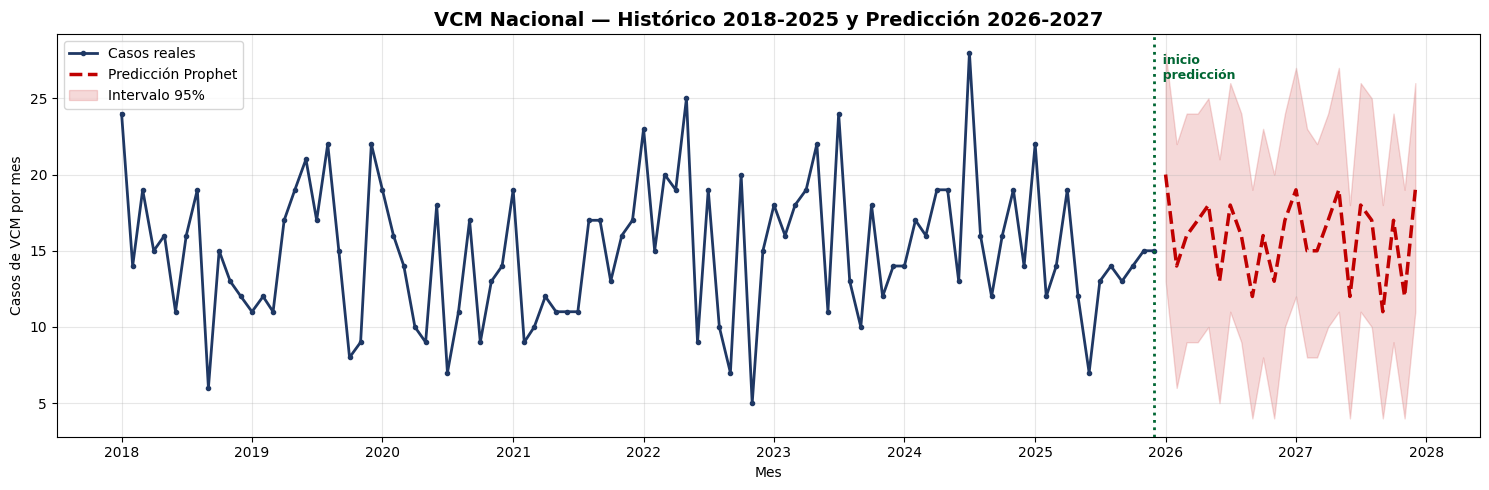

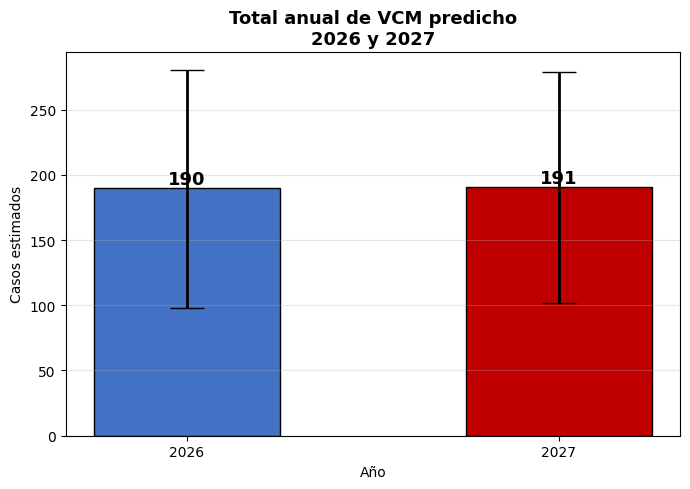

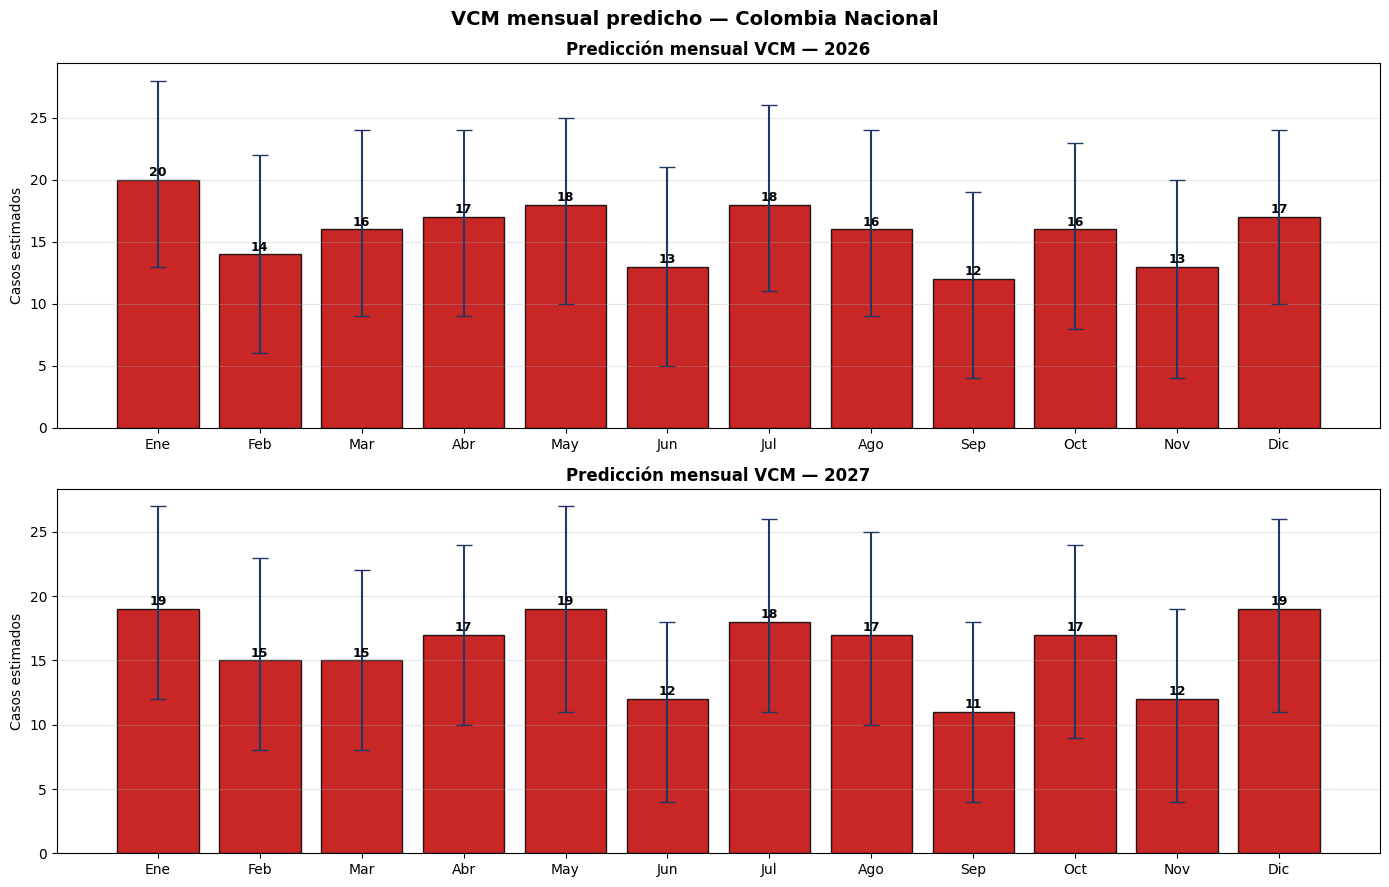

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8C.2 — Gráficas de la predicción nacional total VCM
# ══════════════════════════════════════════════════════════════

# Filtrar solo las predicciones futuras
futuro_total = pred_total[pred_total['ds'] > ultimo_total]

# ── GRÁFICA 1: Histórico + Predicción ────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_p_total['ds'], df_p_total['y'],
        color='#1F3864', linewidth=2, marker='o', markersize=3, label='Casos reales')
ax.plot(futuro_total['ds'], futuro_total['yhat'],
        color='#C00000', linewidth=2.5, linestyle='--', label='Predicción Prophet')
ax.fill_between(futuro_total['ds'],
                futuro_total['yhat_lower'], futuro_total['yhat_upper'],
                color='#C00000', alpha=0.15, label='Intervalo 95%')
ax.axvline(ultimo_total, color='#006633', linestyle=':', linewidth=2)
ax.text(ultimo_total, ax.get_ylim()[1] * 0.9, '  inicio\n  predicción',
        color='#006633', fontsize=9, fontweight='bold')

ax.set_title('VCM Nacional — Histórico 2018-2025 y Predicción 2026-2027',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Casos de VCM por mes')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── GRÁFICA 2: Total anual predicho ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colores_barras = ['#4472C4', '#C00000']
bars = ax.bar(resumen_total['anio'].astype(str), resumen_total['prediccion'],
              color=colores_barras, edgecolor='black', width=0.5)
ax.errorbar(
    resumen_total['anio'].astype(str), resumen_total['prediccion'],
    yerr=[resumen_total['prediccion'] - resumen_total['minimo'],
          resumen_total['maximo'] - resumen_total['prediccion']],
    fmt='none', color='black', capsize=12, linewidth=2
)
for bar, v in zip(bars, resumen_total['prediccion']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3,
            f'{int(v):,}', ha='center', fontweight='bold', fontsize=13)

ax.set_title('Total anual de VCM predicho\n2026 y 2027', fontsize=13, fontweight='bold')
ax.set_ylabel('Casos estimados')
ax.set_xlabel('Año')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── GRÁFICA 3: Mensual 2026 y 2027 ───────────────────────────
MESES_NOMBRE = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for idx, anio in enumerate([2026, 2027]):
    datos_anio = futuro_total[futuro_total['ds'].dt.year == anio].copy()
    ax = axes[idx]
    bars = ax.bar(range(1, len(datos_anio)+1), datos_anio['yhat'],
                  color='#C00000', edgecolor='black', alpha=0.85)
    ax.errorbar(
        range(1, len(datos_anio)+1), datos_anio['yhat'],
        yerr=[datos_anio['yhat'] - datos_anio['yhat_lower'],
              datos_anio['yhat_upper'] - datos_anio['yhat']],
        fmt='none', color='#1F3864', capsize=6, linewidth=1.5
    )
    for bar, v in zip(bars, datos_anio['yhat']):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                str(int(v)), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Predicción mensual VCM — {anio}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(datos_anio)+1))
    ax.set_xticklabels(MESES_NOMBRE[:len(datos_anio)])
    ax.set_ylabel('Casos estimados')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('VCM mensual predicho — Colombia Nacional',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8D — Predicción por Circunstancia del Hecho (top N categorías)

Aquí está la **extensión clave**: en lugar de predecir solo el total de VCM, entrenamos
un modelo Prophet separado para cada circunstancia principal.

**¿Cómo se seleccionan las categorías?**
Tomamos las N circunstancias con más registros históricos. El umbral mínimo (`MIN_CASOS_TOTAL`)
filtra categorías con muy pocos datos donde Prophet no tendría suficiente información.

**¿Qué produce?**
- Un modelo Prophet por circunstancia
- Predicción mensual 2026-2027 para cada una
- Gráfica comparativa de todas las circunstancias
- Tabla resumen exportable


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8D — Identificar las circunstancias principales
# ══════════════════════════════════════════════════════════════

# ── Parámetros ajustables ──────────────────────────────────────
TOP_N           = 8     # Máximo de circunstancias a modelar
MIN_CASOS_TOTAL = 30    # Mínimo de casos históricos para incluir
MIN_MESES       = 24    # Mínimo de meses con al menos 1 caso
# ──────────────────────────────────────────────────────────────

# Normalizar circunstancias (mayúsculas, sin espacios extra)
df_ts['CIRC_NORM'] = df_ts[COL_CIRC].str.upper().str.strip()

# Conteo total por circunstancia
conteo_circ = (
    df_ts.groupby('CIRC_NORM')
    .size()
    .reset_index(name='total')
    .sort_values('total', ascending=False)
)

# Contar meses activos por circunstancia (para validar que hay señal)
meses_activos = (
    df_ts.groupby(['CIRC_NORM','fecha'])
    .size()
    .reset_index()
    .groupby('CIRC_NORM')
    .size()
    .reset_index(name='meses_activos')
)

conteo_circ = conteo_circ.merge(meses_activos, on='CIRC_NORM', how='left')

# Filtrar por mínimos
circ_validas = conteo_circ[
    (conteo_circ['total'] >= MIN_CASOS_TOTAL) &
    (conteo_circ['meses_activos'] >= MIN_MESES)
].head(TOP_N)

print('=== CIRCUNSTANCIAS SELECCIONADAS PARA MODELAR ===')
print(f'Criterios: ≥{MIN_CASOS_TOTAL} casos totales y ≥{MIN_MESES} meses activos')
print(f'Top {TOP_N} circunstancias:')
print(circ_validas[['CIRC_NORM','total','meses_activos']].to_string(index=False))

CIRCUNSTANCIAS_MODELO = circ_validas['CIRC_NORM'].tolist()
print(f'\nTotal a modelar: {len(CIRCUNSTANCIAS_MODELO)}')

=== CIRCUNSTANCIAS SELECCIONADAS PARA MODELAR ===
Criterios: ≥30 casos totales y ≥24 meses activos
Top 8 circunstancias:
                              CIRC_NORM  total  meses_activos
                            FEMINICIDIO    922             96
                              SICARIATO    448             38
                    VIOLENCIA DE PAREJA    416             81
       VIOLENCIA ENTRE OTROS FAMILIARES     82             53
VIOLENCIA A NIÑOS, NIÑAS Y ADOLESCENTES     61             43

Total a modelar: 5


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8D.2 — Entrenar un modelo Prophet por circunstancia
# ══════════════════════════════════════════════════════════════

resultados_por_circ = {}  # diccionario: circunstancia → {pred, df_p, ultimo}

for circ in CIRCUNSTANCIAS_MODELO:
    # Filtrar registros de esta circunstancia
    df_circ = df_ts[df_ts['CIRC_NORM'] == circ].copy()

    # Construir serie mensual con corrección de 2023
    serie_circ = construir_serie_mensual(df_circ, corregir_2023=True, nombre=circ[:40])

    if len(serie_circ) < 18:
        print(f'  [{circ[:40]}] Insuficientes meses ({len(serie_circ)}) — omitida')
        continue

    try:
        modelo_c, pred_c, df_p_c, ultimo_c = entrenar_prophet(
            serie_circ,
            nombre=circ[:40],
            meses_futuros=24
        )
        resultados_por_circ[circ] = {
            'pred':   pred_c,
            'df_p':   df_p_c,
            'ultimo': ultimo_c,
            'serie':  serie_circ
        }
    except Exception as e:
        print(f'  [{circ[:40]}] Error al entrenar: {e}')

print(f'\n✓ Modelos entrenados exitosamente: {len(resultados_por_circ)}')

  [FEMINICIDIO] Meses de 2023 corregidos: 12/12

[FEMINICIDIO] Modelo entrenado | Último dato: 2025-12 | Proyección hasta: 2027-12
  [SICARIATO] Meses de 2023 corregidos: 2/12

[SICARIATO] Modelo entrenado | Último dato: 2025-12 | Proyección hasta: 2027-12
  [VIOLENCIA DE PAREJA] Meses de 2023 corregidos: 0/12

[VIOLENCIA DE PAREJA] Modelo entrenado | Último dato: 2025-12 | Proyección hasta: 2027-12
  [VIOLENCIA ENTRE OTROS FAMILIARES] Meses de 2023 corregidos: 0/12

[VIOLENCIA ENTRE OTROS FAMILIARES] Modelo entrenado | Último dato: 2025-11 | Proyección hasta: 2027-11
  [VIOLENCIA A NIÑOS, NIÑAS Y ADOLESCENTES] Meses de 2023 corregidos: 0/12

[VIOLENCIA A NIÑOS, NIÑAS Y ADOLESCENTES] Modelo entrenado | Último dato: 2025-12 | Proyección hasta: 2027-12

✓ Modelos entrenados exitosamente: 5


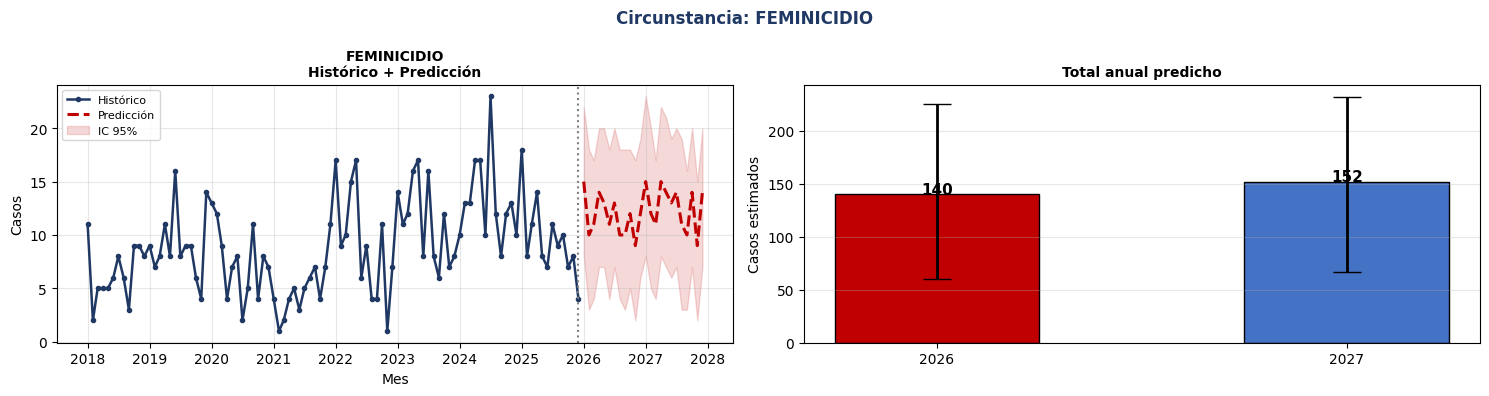

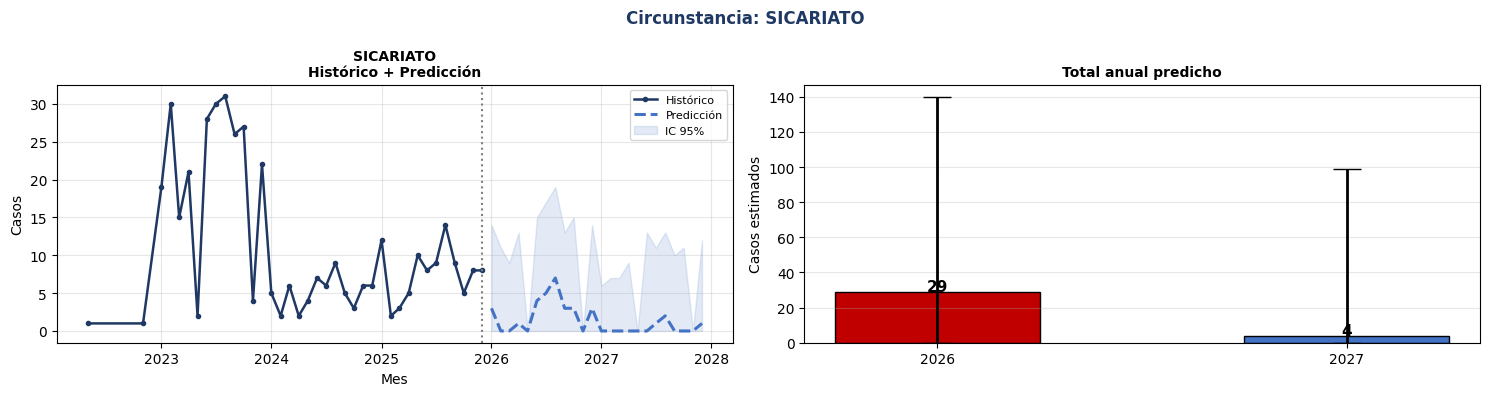

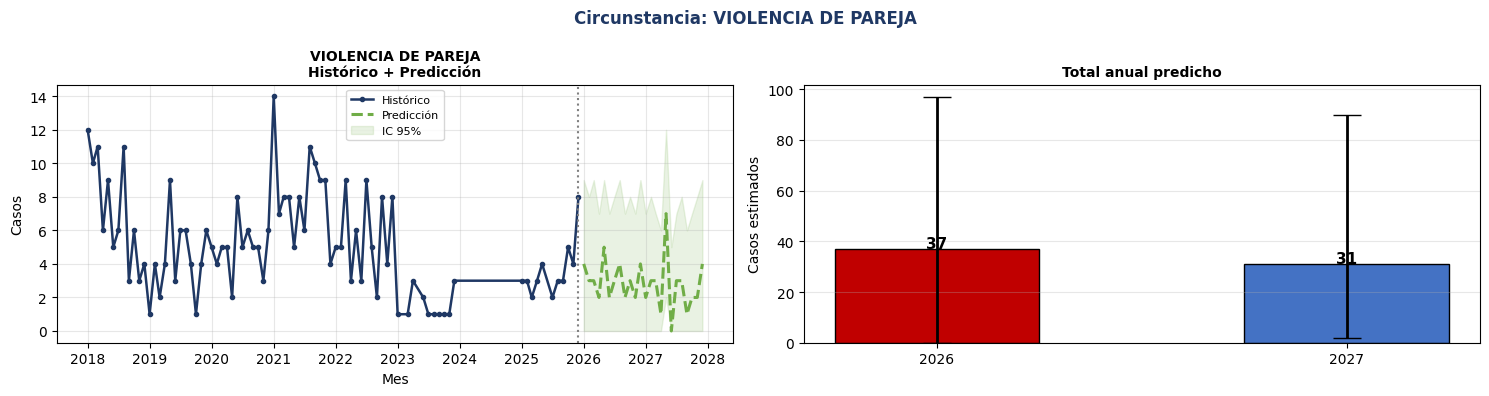

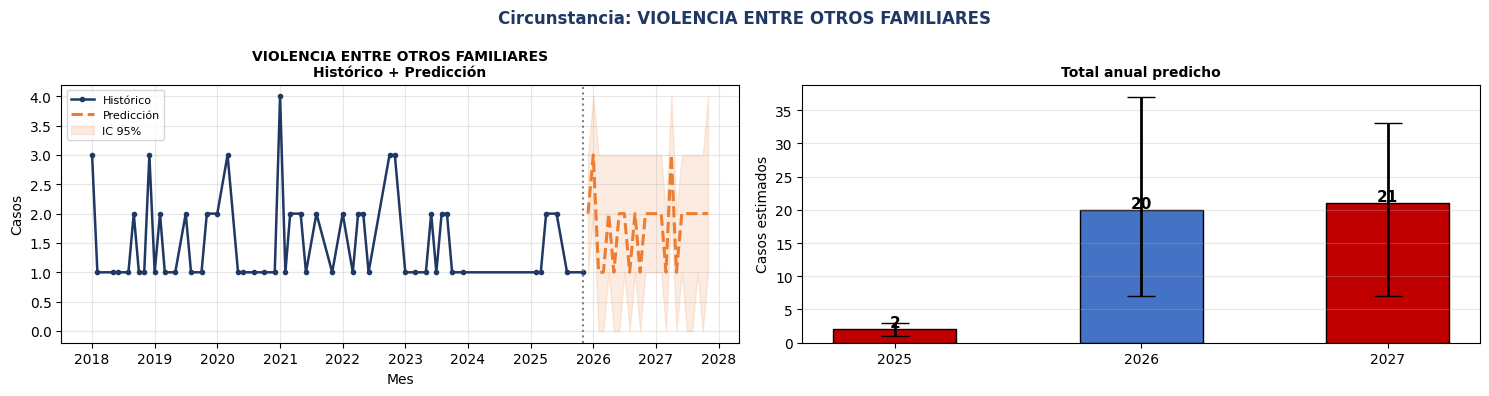

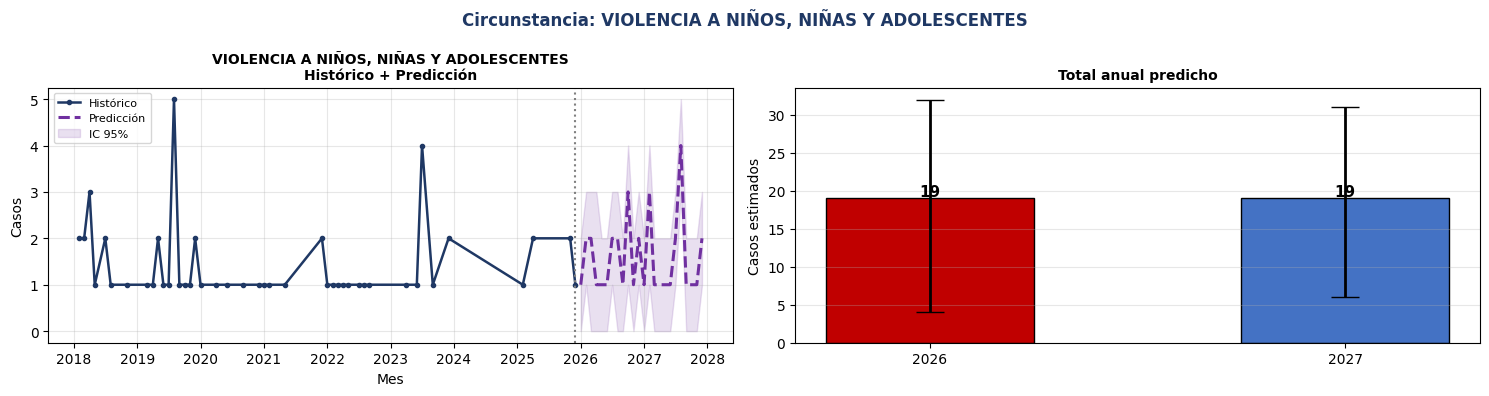

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8D.3 — Gráficas individuales por circunstancia
# ══════════════════════════════════════════════════════════════

COLORES_CIRC = [
    '#C00000', '#4472C4', '#70AD47', '#ED7D31',
    '#7030A0', '#00B0F0', '#FF00FF', '#92D050'
]

for i, (circ, datos) in enumerate(resultados_por_circ.items()):
    pred_c   = datos['pred']
    df_p_c   = datos['df_p']
    ultimo_c = datos['ultimo']
    color_c  = COLORES_CIRC[i % len(COLORES_CIRC)]

    futuro_c = pred_c[pred_c['ds'] > ultimo_c]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Histórico + Predicción
    axes[0].plot(df_p_c['ds'], df_p_c['y'],
                 color='#1F3864', lw=1.8, marker='o', ms=3, label='Histórico')
    axes[0].plot(futuro_c['ds'], futuro_c['yhat'],
                 color=color_c, lw=2.2, linestyle='--', label='Predicción')
    axes[0].fill_between(futuro_c['ds'],
                         futuro_c['yhat_lower'], futuro_c['yhat_upper'],
                         color=color_c, alpha=0.15, label='IC 95%')
    axes[0].axvline(ultimo_c, color='gray', linestyle=':', lw=1.5)
    axes[0].set_title(f'{circ[:50]}\nHistórico + Predicción', fontsize=10, fontweight='bold')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel('Casos')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Comparativa 2026 vs 2027
    anual_c = (
        futuro_c.assign(anio=futuro_c['ds'].dt.year)
        .groupby('anio')
        .agg(pred=('yhat','sum'), lower=('yhat_lower','sum'), upper=('yhat_upper','sum'))
        .reset_index()
    )
    bars_c = axes[1].bar(anual_c['anio'].astype(str), anual_c['pred'],
                         color=[COLORES_CIRC[0], COLORES_CIRC[1]], edgecolor='black', width=0.5)
    axes[1].errorbar(
        anual_c['anio'].astype(str), anual_c['pred'],
        yerr=[anual_c['pred'] - anual_c['lower'], anual_c['upper'] - anual_c['pred']],
        fmt='none', color='black', capsize=10, lw=2
    )
    for bar, v in zip(bars_c, anual_c['pred']):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                     f'{int(v):,}', ha='center', fontweight='bold', fontsize=11)
    axes[1].set_title('Total anual predicho', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Casos estimados')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Circunstancia: {circ[:60]}',
                 fontsize=12, fontweight='bold', color='#1F3864')
    plt.tight_layout()
    plt.show()

## 8E — Gráfica comparativa consolidada y tabla de resumen

Esta sección consolida las predicciones de todas las circunstancias en una sola vista
para facilitar comparaciones y el análisis de cuáles categorías tienen tendencia creciente
o decreciente.


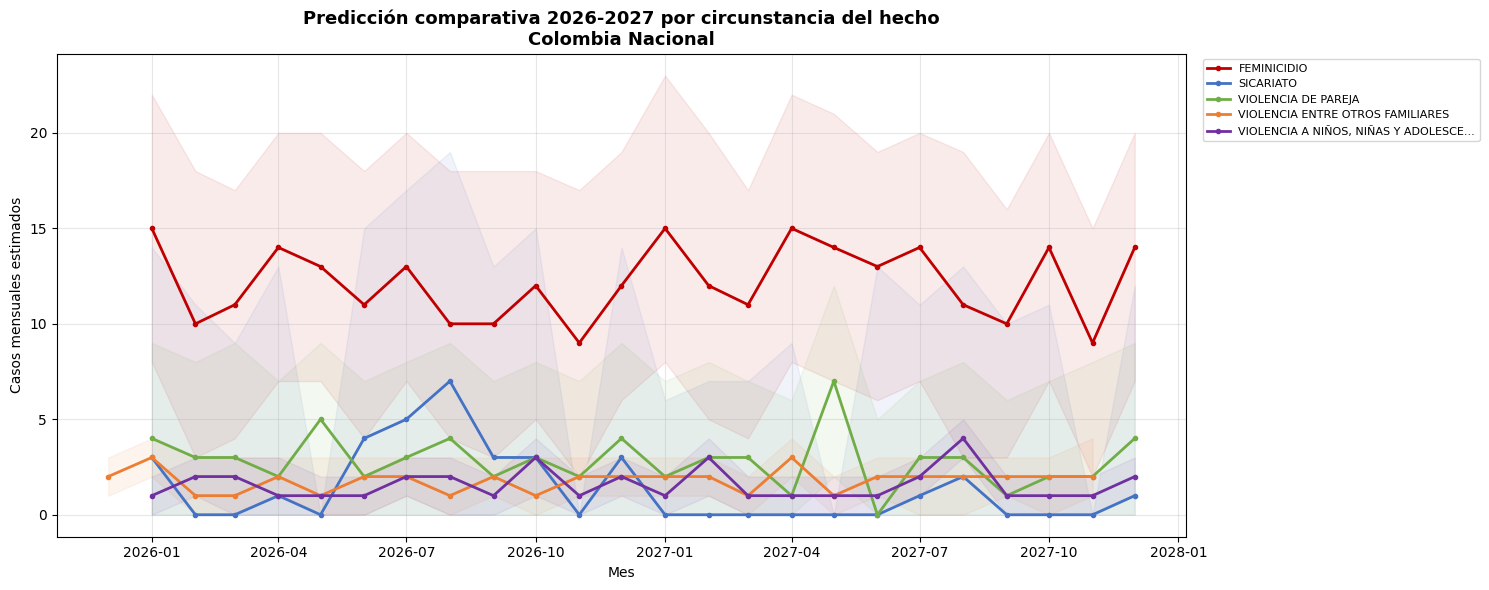

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8E. — Gráfica comparativa: todas las circunstancias juntas
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(15, 6))

for i, (circ, datos) in enumerate(resultados_por_circ.items()):
    pred_c   = datos['pred']
    ultimo_c = datos['ultimo']
    color_c  = COLORES_CIRC[i % len(COLORES_CIRC)]

    futuro_c = pred_c[pred_c['ds'] > ultimo_c]
    etiqueta = circ[:35] + ('...' if len(circ) > 35 else '')

    ax.plot(futuro_c['ds'], futuro_c['yhat'],
            color=color_c, lw=2, marker='o', ms=3, label=etiqueta)
    ax.fill_between(futuro_c['ds'],
                    futuro_c['yhat_lower'], futuro_c['yhat_upper'],
                    color=color_c, alpha=0.08)

ax.set_title('Predicción comparativa 2026-2027 por circunstancia del hecho\nColombia Nacional',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Casos mensuales estimados')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8E.2 — Tabla resumen exportable: predicciones anuales
#         por circunstancia para 2026 y 2027
# ══════════════════════════════════════════════════════════════

filas_resumen = []

for circ, datos in resultados_por_circ.items():
    pred_c   = datos['pred']
    ultimo_c = datos['ultimo']

    # Último año completo histórico (para comparar)
    anio_ult = ultimo_c.year
    historico_ult = (
        pred_c[pred_c['ds'].dt.year == anio_ult]
        ['yhat'].sum()
    )

    for anio in [2026, 2027]:
        datos_anio = pred_c[
            (pred_c['ds'] > ultimo_c) &
            (pred_c['ds'].dt.year == anio)
        ]
        if datos_anio.empty:
            continue

        pred_anual  = int(datos_anio['yhat'].sum())
        lower_anual = int(datos_anio['yhat_lower'].sum())
        upper_anual = int(datos_anio['yhat_upper'].sum())
        variacion   = ((pred_anual - historico_ult) / (historico_ult + 1)) * 100

        filas_resumen.append({
            'Circunstancia':  circ,
            'Año':            anio,
            'Predicción':     pred_anual,
            'Mínimo (IC95%)': lower_anual,
            'Máximo (IC95%)': upper_anual,
            f'Var% vs {anio_ult}': round(variacion, 1)
        })

df_resumen = pd.DataFrame(filas_resumen)

print('=== TABLA RESUMEN — PREDICCIONES POR CIRCUNSTANCIA ===')
print(df_resumen.to_string(index=False))

# Exportar a CSV para documentación
df_resumen.to_csv('predicciones_circunstancias_2026_2027.csv', index=False)
print('\n✓ Tabla exportada: predicciones_circunstancias_2026_2027.csv')

=== TABLA RESUMEN — PREDICCIONES POR CIRCUNSTANCIA ===
                          Circunstancia  Año  Predicción  Mínimo (IC95%)  Máximo (IC95%)  Var% vs 2025
                            FEMINICIDIO 2026         140              60             225           3.7
                            FEMINICIDIO 2027         152              67             232          12.5
                              SICARIATO 2026          29               0             140         -56.5
                              SICARIATO 2027           4               0              99         -92.8
                    VIOLENCIA DE PAREJA 2026          37               0              97           0.0
                    VIOLENCIA DE PAREJA 2027          31               2              90         -15.8
       VIOLENCIA ENTRE OTROS FAMILIARES 2026          20               7              37          90.9
       VIOLENCIA ENTRE OTROS FAMILIARES 2027          21               7              33         100.0
VIOLENCIA A NIÑOS,

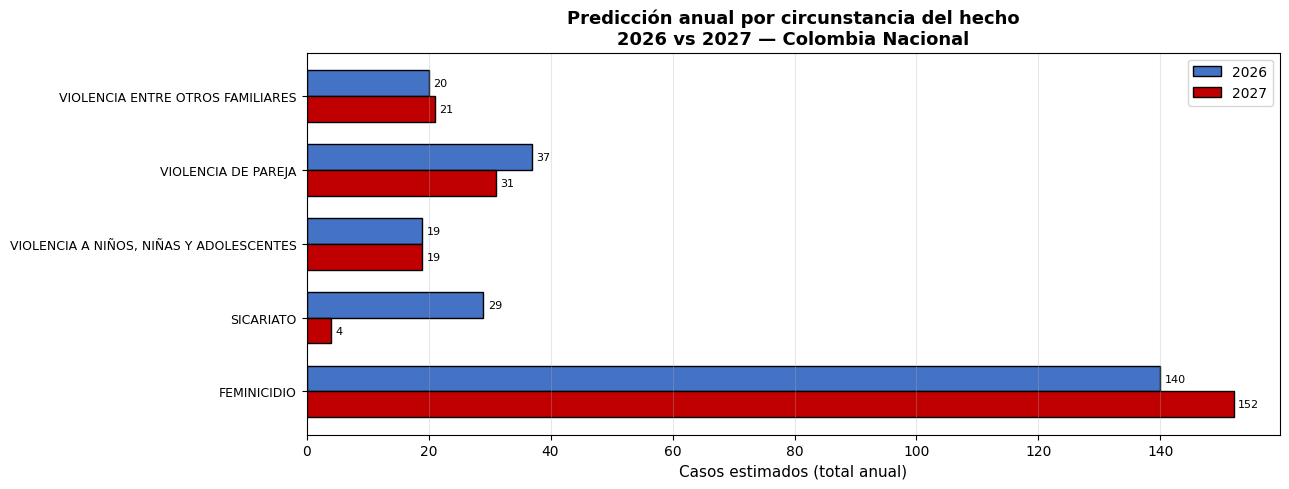

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8E.3 — Gráfica de barras agrupadas: predicción anual
#         por circunstancia (2026 vs 2027)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, max(5, len(df_barras) * 0.7)))

x       = np.arange(len(df_barras))
ancho   = 0.35

if 2026 in df_barras.columns:
    bars_2026 = ax.barh(x + ancho/2, df_barras[2026], ancho,
                        label='2026', color='#4472C4', edgecolor='black')

    # Etiquetas 2026
    ax.bar_label(bars_2026, fmt='%.0f', padding=3, fontsize=8)

if 2027 in df_barras.columns:
    bars_2027 = ax.barh(x - ancho/2, df_barras[2027], ancho,
                        label='2027', color='#C00000', edgecolor='black')

    # Etiquetas 2027
    ax.bar_label(bars_2027, fmt='%.0f', padding=3, fontsize=8)

ax.set_yticks(x)
ax.set_yticklabels(df_barras.index, fontsize=9)
ax.set_xlabel('Casos estimados (total anual)', fontsize=11)
ax.set_title('Predicción anual por circunstancia del hecho\n2026 vs 2027 — Colombia Nacional',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()